# Business Entity Resolution — Exploratory Data Analysis

**Scope: EDA only.** No embeddings, blocking indexes, classifiers or matching pipeline are built here.
The goal is to understand the data well enough to make informed choices in the next (modelling) phase.

**Task recap.** Three independent sources describe businesses with `entity_id`, `business_name`, `business_address`, `country`.
Source 1 (S1) is a de-duplicated reference; for each S1 entity we must later find all matching S2/S3 records.
Scoring is macro-averaged per-S1 **F0.5** (precision-weighted), and singletons (no match) count.

**How this notebook handles ~2.5 GB of data**

* All full-dataset statistics use **Polars lazy scans with the streaming engine** (plus DuckDB for type sniffing); no file is ever fully loaded into pandas.
* Detailed, row-level analyses use **deterministic hash samples** (`hash(entity_id) % 10 000 < k`), so results are reproducible.
* Every file is read as **strings only** (`infer_schema=False`) and TSV quoting is disabled (`quote_char=None`), because addresses contain commas and quotes.
* Original files are never modified. Tables are saved to `eda/results/*.csv` and figures to `eda/results/*.png`.

**Contents**
1. Dataset overview · 2. Source comparison · 3. Business names · 4. Addresses · 5. Conservative normalisation ·
6. Ground truth · 7. Name vs address information · 8. Train vs test · 9. Key findings

## 0. Setup

In [1]:
import time
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

warnings.filterwarnings("ignore", category=DeprecationWarning)  # Polars 2.0 `empty_as_null` notice on explode
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_width_chars(250)
pl.Config.set_tbl_hide_dataframe_shape(True)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 250)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
DATA = ROOT / "dataset"
OUT = ROOT / "eda" / "results"
OUT.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "test"]
SOURCES = ["S1", "S2", "S3"]
SOURCE_FILES = {(sp, s): DATA / sp / f"{sp}_source{s[1]}.tsv" for sp in SPLITS for s in SOURCES}
GT_FILE = DATA / "train" / "train_ground_truth.tsv"
TEXT_COLS = ["business_name", "business_address"]
SEED = 42
T0 = time.time()

print("polars", pl.__version__, "| duckdb", duckdb.__version__, "| pandas", pd.__version__)
print("data dir:", DATA.resolve())
print("results dir:", OUT.resolve())

polars 1.44.2 | duckdb 1.5.5 | pandas 3.0.6
data dir: C:\Users\rocks\Downloads\6ab10eb3b23ba_student_resource\student_resource\dataset
results dir: C:\Users\rocks\Downloads\6ab10eb3b23ba_student_resource\student_resource\eda\results


### Reusable helpers — I/O

In [2]:
def scan_source(split: str, source: str) -> pl.LazyFrame:
    '''Lazily scan one source TSV. Every column is a string; quoting is disabled (fields contain commas/quotes).'''
    return (pl.scan_csv(SOURCE_FILES[(split, source)], separator="\t", quote_char=None,
                        infer_schema=False, encoding="utf8-lossy")
              .with_columns(split=pl.lit(split), source=pl.lit(source)))


def scan_sources(splits=SPLITS, sources=SOURCES) -> pl.LazyFrame:
    '''Vertical concatenation of several source files (still lazy).'''
    return pl.concat([scan_source(sp, s) for sp in splits for s in sources])


def scan_gt() -> pl.LazyFrame:
    return pl.scan_csv(GT_FILE, separator="\t", quote_char=None, infer_schema=False)


def collect(lf: pl.LazyFrame) -> pl.DataFrame:
    '''Execute a lazy query with the streaming engine (bounded memory).'''
    return lf.collect(engine="streaming")


def hash_sample(lf: pl.LazyFrame, pct: float, col: str = "entity_id") -> pl.LazyFrame:
    '''Deterministic ~pct % sample based on a hash of the id column.'''
    return lf.filter(pl.col(col).hash(SEED) % 10_000 < int(pct * 100))


def order(df: pl.DataFrame) -> pl.DataFrame:
    '''Sort train before test, then by source / country when present.'''
    keys = []
    if "split" in df.columns:
        keys.append(pl.col("split").replace_strict({"train": 0, "test": 1}, default=9, return_dtype=pl.Int8))
    keys += [c for c in ("source", "country") if c in df.columns]
    return df.sort(keys) if keys else df


def save_table(df, name: str):
    '''Persist a summary table to eda/results/<name>.csv and return it for display.'''
    (df.to_pandas() if isinstance(df, pl.DataFrame) else df).to_csv(OUT / f"{name}.csv", index=False)
    return df


def save_fig(fig, name: str):
    fig.savefig(OUT / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

### Reusable helpers — text expressions

In [3]:
LATIN_DIACRITIC = r"[\p{Latin}&&[^A-Za-z]]"      # Latin letters outside plain ASCII (é, ç, ó ...)
NON_LATIN_LETTER = r"[\p{L}&&[^\p{Latin}]]"      # any letter from a non-Latin script
SCRIPTS = ["Devanagari", "Bengali", "Gurmukhi", "Gujarati", "Oriya", "Tamil", "Telugu", "Kannada",
           "Malayalam", "Arabic", "Cyrillic", "Greek", "Han", "Hangul", "Hiragana", "Katakana", "Thai", "Hebrew"]


def n_chars(col):
    return pl.col(col).str.len_chars()


def n_words(col):
    return pl.col(col).str.count_matches(r"\S+")


def normalize_expr(col: str) -> pl.Expr:
    '''Conservative normalisation - nothing is dropped except punctuation:
    NFKC -> lowercase -> remove apostrophes -> other punctuation to space -> collapse whitespace.
    Keeps all words (legal suffixes, street types, stop-words) and keeps '&' and combining marks (Indic vowel signs).'''
    return (pl.col(col).str.normalize("NFKC").str.to_lowercase()
            .str.replace_all(r"['’‘`´]", "")
            .str.replace_all(r"[^\p{L}\p{M}\p{N}\s&]", " ")
            .str.replace_all(r"\s+", " ")
            .str.strip_chars())


def token_jaccard(a: str, b: str) -> pl.Expr:
    '''Jaccard similarity of whitespace token sets of two (already normalised) string columns.'''
    ta, tb = pl.col(a).str.split(" ").list.unique(), pl.col(b).str.split(" ").list.unique()
    inter = ta.list.set_intersection(tb).list.len()
    union = ta.list.set_union(tb).list.len()
    return pl.when(union > 0).then(inter / union)


def text_flags(col: str) -> dict:
    '''Boolean noise indicators for a raw text column.'''
    c = pl.col(col)
    has_latin = c.str.contains(r"[A-Za-z]")
    return {
        "has_digit": c.str.contains(r"\d"),
        "has_punct": c.str.contains(r"[^\p{L}\p{M}\p{N}\s]"),
        "has_ampersand": c.str.contains("&", literal=True),
        "url_or_domain": c.str.contains(r"(?i)https?://|www\.|\.(com|net|org|biz|info|in|co|fr|us)\b"),
        "non_ascii": c.str.contains(r"[^\x00-\x7F]"),
        "latin_diacritics": c.str.contains(LATIN_DIACRITIC),
        "non_latin_script": c.str.contains(NON_LATIN_LETTER),
        "all_upper": has_latin & (c == c.str.to_uppercase()),
        "all_lower": has_latin & (c == c.str.to_lowercase()),
        "repeated_space": c.str.contains(r"\s{2,}"),
        "lead_trail_space": c.str.contains(r"^\s|\s$"),
        "odd_symbols": c.str.contains(r"[#@*_|~^<>{}\[\]\\]"),
        "replacement_char": c.str.contains("\ufffd", literal=True),
    }


def flag_rates(lf: pl.LazyFrame, col: str, flags: dict, by=("split", "source")) -> pl.DataFrame:
    '''% of non-null rows for which each flag is true, per group (full data, streaming).'''
    aggs = [(e.mean() * 100).round(2).alias(k) for k, e in flags.items()]
    return order(collect(lf.filter(pl.col(col).is_not_null()).group_by(*by).agg(pl.len().alias("rows"), *aggs)))


def flag_examples(col: str, flags: dict, split="train", pct=2.0, n=3, sources=SOURCES) -> pl.DataFrame:
    '''Real examples (hash-sampled) for each flag - n per source.'''
    out = []
    for name, expr in flags.items():
        for s in sources:
            ex = collect(hash_sample(scan_source(split, s), pct).filter(expr)
                         .select(pl.lit(name).alias("pattern"), "entity_id", "country", col).head(n))
            out.append(ex)
    return pl.concat(out)


def value_hist(lf: pl.LazyFrame, expr: pl.Expr, by=("split", "source"), clip=150) -> pl.DataFrame:
    '''Histogram counts of an integer expression (clipped at `clip`) per group.'''
    return collect(lf.group_by(*by, expr.clip(0, clip).alias("value")).len())


def plot_hist_panels(h: pl.DataFrame, panel: str, line: str, title: str, xlabel: str, fname: str, xmax=None):
    '''One panel per value of `panel`, one line per value of `line`; y = % of records in the group.'''
    panels = [p for p in ["train", "test", "US", "India", "France"] if p in h[panel].unique().to_list()] \
        or sorted(h[panel].unique().to_list())
    fig, axes = plt.subplots(1, len(panels), figsize=(5.2 * len(panels), 3.6), sharey=True, squeeze=False)
    for ax, p in zip(axes[0], panels):
        d = h.filter(pl.col(panel) == p)
        for g in sorted(d[line].unique().to_list()):
            dd = d.filter(pl.col(line) == g).sort("value")
            ax.plot(dd["value"], dd["len"] / dd["len"].sum() * 100, label=str(g), lw=1.5)
        ax.set_title(f"{panel} = {p}")
        ax.set_xlabel(xlabel)
        if xmax:
            ax.set_xlim(0, xmax)
        ax.legend(fontsize=8)
    axes[0][0].set_ylabel("% of records")
    fig.suptitle(title, y=1.02)
    save_fig(fig, fname)

## 1. Dataset overview

### 1.1 Files, row counts, id integrity and missing values (full data)

In [4]:
def file_overview() -> pl.DataFrame:
    rows = []
    for (sp, s), path in SOURCE_FILES.items():
        st = collect(scan_source(sp, s).select(
            rows=pl.len(),
            unique_ids=pl.col("entity_id").n_unique(),
            wrong_id_prefix=(~pl.col("entity_id").str.contains(rf"^{s}-\d+$")).sum(),
            null_name=pl.col("business_name").is_null().sum(),
            null_address=pl.col("business_address").is_null().sum(),
            null_country=pl.col("country").is_null().sum(),
            blank_name=(pl.col("business_name").str.strip_chars() == "").sum(),
            blank_address=(pl.col("business_address").str.strip_chars() == "").sum(),
        )).row(0, named=True)
        rows.append({"split": sp, "source": s, "file": path.name, "size_mb": round(path.stat().st_size / 1e6, 1), **st})
    df = pl.DataFrame(rows).with_columns(duplicate_ids=pl.col("rows") - pl.col("unique_ids"),
                                         pct_null_address=(pl.col("null_address") / pl.col("rows") * 100).round(2))
    return order(df)


overview = save_table(file_overview(), "01_file_overview")
overview

split,source,file,size_mb,rows,unique_ids,wrong_id_prefix,null_name,null_address,null_country,blank_name,blank_address,duplicate_ids,pct_null_address
str,str,str,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
"""train""","""S1""","""train_source1.tsv""",210.1,2206821,2206821,0,0,0,0,0,0,0,0.0
"""train""","""S2""","""train_source2.tsv""",489.3,5034616,5034616,0,0,168967,0,0,0,0,3.36
"""train""","""S3""","""train_source3.tsv""",503.7,5285603,5285603,0,0,175916,0,0,0,0,3.33
"""test""","""S1""","""test_source1.tsv""",175.0,1732544,1732544,0,0,0,0,0,0,0,0.0
"""test""","""S2""","""test_source2.tsv""",509.5,4887273,4887273,0,0,129408,0,0,0,0,2.65
"""test""","""S3""","""test_source3.tsv""",506.0,5082316,5082316,0,0,136098,0,0,0,0,2.68


In [5]:
gt_overview = collect(scan_gt().select(
    rows=pl.len(),
    unique_s1=pl.col("source1_entity_id").n_unique(),
    empty_match_lists=pl.col("matched_entity_ids").is_null().sum(),
))
print(f"{GT_FILE.name}: {GT_FILE.stat().st_size / 1e6:.1f} MB")
print(f"Total size of all 7 files: {sum(p.stat().st_size for p in SOURCE_FILES.values()) / 1e9 + GT_FILE.stat().st_size / 1e9:.2f} GB")
gt_overview

train_ground_truth.tsv: 127.0 MB
Total size of all 7 files: 2.52 GB


rows,unique_s1,empty_match_lists
u32,u32,u32
2206821,2206821,123247


**Interpretation.** 2.52 GB in total: **24.2 M source records** (train 12.5 M, test 11.7 M) plus 2.2 M ground-truth rows. All six source files parse cleanly with 4 columns. Every `entity_id` is unique and carries the correct `S1-`/`S2-`/`S3-` prefix, and no name or country is missing. The only missing field is **`business_address` in S2/S3** (≈3.3 % in train, ≈2.7 % in test). S1 always has an address. Empty strings do not occur separately from nulls. The GT file has exactly one row per train S1 entity, and 123,247 of them have an empty match list.

### 1.2 Columns and data types

In [6]:
schemas = {f"{sp}/{s}": list(scan_source(sp, s).collect_schema().items()) for sp, s in SOURCE_FILES}
print("Polars schema (read as strings by design):")
for k, v in schemas.items():
    print(f"  {k:10s}", [c for c, _ in v if c not in ("split", "source")])
print("GT columns:", scan_gt().collect_schema().names())

# What would type inference make of these files? DuckDB's CSV sniffer on train S1:
duckdb.sql(f'''DESCRIBE SELECT * FROM read_csv('{SOURCE_FILES[("train", "S1")].as_posix()}',
               delim='\t', header=true, quote='', escape='', all_varchar=false)''').df()

Polars schema (read as strings by design):
  train/S1   ['entity_id', 'business_name', 'business_address', 'country']
  train/S2   ['entity_id', 'business_name', 'business_address', 'country']
  train/S3   ['entity_id', 'business_name', 'business_address', 'country']
  test/S1    ['entity_id', 'business_name', 'business_address', 'country']
  test/S2    ['entity_id', 'business_name', 'business_address', 'country']
  test/S3    ['entity_id', 'business_name', 'business_address', 'country']
GT columns: ['source1_entity_id', 'matched_entity_ids']


,column_name,column_type,null,key,default,extra
0,entity_id,VARCHAR,YES,None,None,None
1,business_name,VARCHAR,YES,None,None,None
2,business_address,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None


In [7]:
pl.concat([collect(scan_source(sp, s).head(2)) for sp, s in SOURCE_FILES])

entity_id,business_name,business_address,country,split,source
str,str,str,str,str,str
"""S1-925783039""","""Orelee's Barbershop""","""1795 Westchester Drive, High Point, NC""","""US""","""train""","""S1"""
"""S1-773889195""","""Prime Money""","""17560 Ellis Road, Tahlequah, OK""","""US""","""train""","""S1"""
"""S2-166376419""","""राम मार्केटिंग प्राइवेट लिमिटेड""","""KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi""","""India""","""train""","""S2"""
"""S2-764573417""","""-- Holloway Peak Inc Seafood""","""105 ELM ST, MORGANTON, NC""","""US""","""train""","""S2"""
"""S3-202863386""","""wilfordhancock.com""","""Mack Rd, Haltom City, Texas""","""US""","""train""","""S3"""
"""S3-859268022""","""International South Consultants Private Ltd""",null,"""India""","""train""","""S3"""
"""S1-714132312""","""Zephay Labs Inc""","""2621 Cotten Road, Tyler, TX""","""US""","""test""","""S1"""
"""S1-106407869""","""Vision Partners Corp""","""IA, Iowa City, 1064 Newton Rd, Unit 11""","""US""","""test""","""S1"""
"""S2-192345572""","""Brahma Infosoft""","""COIMATORE COLONY, HUNSUR TQMYSORE DIST., Karnataka""","""India""","""test""","""S2"""


**Interpretation.** Every column is free text. DuckDB's sniffer also infers `VARCHAR` for all four columns, so there are no numeric or date fields to type. The ids are opaque strings (the numeric part carries no order or meaning, and S2/S3 ids are unrelated to S1 ids). The first rows already show several kinds of noise: Devanagari names, `--` prefixes, domain names used as business names, `null` addresses, and reordered components such as `IA, Iowa City, 1064 Newton Rd`.

### 1.3 Country distribution (full data)

In [8]:
country = collect(scan_sources().group_by("split", "source", "country").len("rows"))
country = order(country.with_columns(pct=(pl.col("rows") / pl.col("rows").sum().over("split", "source") * 100).round(2)))
save_table(country, "01_country_distribution")
country.pivot(on=["split", "source"], index="country", values="pct").fill_null(0)

country,"{""train"",""S1""}","{""train"",""S2""}","{""train"",""S3""}","{""test"",""S1""}","{""test"",""S2""}","{""test"",""S3""}"
str,f64,f64,f64,f64,f64,f64
"""India""",40.02,40.08,40.02,46.75,47.32,47.32
"""US""",59.98,59.92,59.98,38.27,38.29,38.28
"""France""",0.0,0.0,0.0,14.98,14.39,14.4


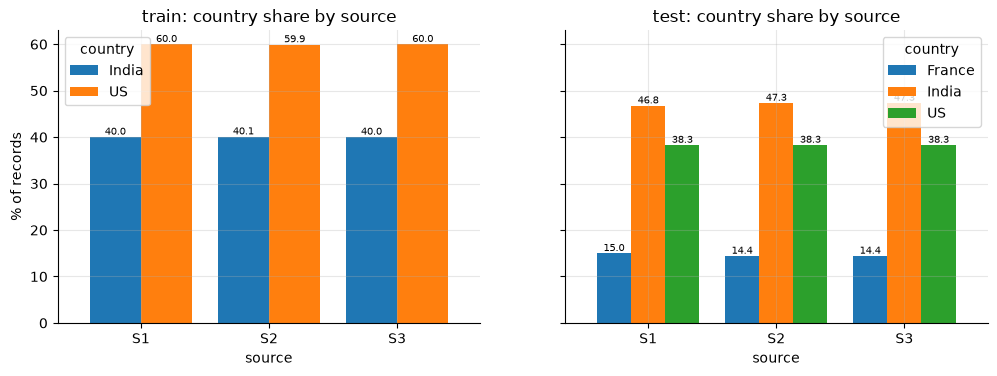

In [9]:
def plot_country_share(df: pl.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
    for ax, sp in zip(axes, SPLITS):
        d = df.filter(pl.col("split") == sp).to_pandas().pivot(index="source", columns="country", values="pct").fillna(0)
        d.plot.bar(ax=ax, rot=0, width=0.8)
        ax.set_title(f"{sp}: country share by source")
        ax.set_ylabel("% of records")
        for cont in ax.containers:
            ax.bar_label(cont, fmt="%.1f", fontsize=7)
    save_fig(fig, "01_country_distribution")


plot_country_share(country)

**Interpretation.** Within a split, the three sources have almost identical country mixes. **Train is US 60 % / India 40 %. Test is India ≈47 %, US ≈38 % and France ≈14.5 %.** France appears **only in test**. `country` is never missing, so it is a reliable coarse partition. The country mix also shifts between train and test, not just by the addition of France.

## 2. Source comparison (S1 vs S2 vs S3)

### 2.1 Length, word-count, missingness and uniqueness profile (full data)

In [10]:
def text_profile(col: str, short: str) -> list:
    L, W = n_chars(col), n_words(col)
    return [
        (pl.col(col).is_null().mean() * 100).round(2).alias(f"{short}_pct_null"),
        L.mean().round(1).alias(f"{short}_len_mean"),
        L.median().alias(f"{short}_len_median"),
        L.quantile(0.95).alias(f"{short}_len_p95"),
        L.max().alias(f"{short}_len_max"),
        W.mean().round(2).alias(f"{short}_words_mean"),
        (pl.col(col).n_unique() / pl.len() * 100).round(2).alias(f"{short}_pct_unique"),
    ]


profile = order(collect(scan_sources().group_by("split", "source").agg(
    pl.len().alias("rows"), *text_profile("business_name", "name"), *text_profile("business_address", "addr"))))
save_table(profile, "02_source_profile")
profile

split,source,rows,name_pct_null,name_len_mean,name_len_median,name_len_p95,name_len_max,name_words_mean,name_pct_unique,addr_pct_null,addr_len_mean,addr_len_median,addr_len_p95,addr_len_max,addr_words_mean,addr_pct_unique
str,str,u32,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,u32,f64,f64
"""train""","""S1""",2206821,0.0,24.0,24.0,37.0,105,3.55,69.75,0.0,52.1,41.0,103.0,256,8.03,96.55
"""train""","""S2""",5034616,0.0,25.1,25.0,40.0,104,3.5,87.43,3.36,47.8,37.0,97.0,249,7.54,86.15
"""train""","""S3""",5285603,0.0,25.2,25.0,42.0,123,3.53,88.01,3.33,48.3,42.0,92.0,240,7.42,87.65
"""test""","""S1""",1732544,0.0,23.8,24.0,36.0,92,3.52,71.51,0.0,57.2,50.0,105.0,268,8.59,96.82
"""test""","""S2""",4887273,0.0,25.7,25.0,42.0,102,3.59,88.21,2.65,51.8,43.0,99.0,269,8.01,86.44
"""test""","""S3""",5082316,0.0,25.7,25.0,42.0,103,3.6,88.97,2.68,50.1,44.0,95.0,267,7.72,87.69


**Interpretation.** Names are short (median 24–25 characters, ≈3.5 words) and similar across sources. Addresses are longer (median 37–50 characters, 7.4–8.6 words). S1 addresses are the most complete: S1 has no missing addresses and 96.5 % of them are unique. S2/S3 have **more distinct names** (87–89 % unique vs ≈70 % for S1) because their spelling noise creates many variants. S1 has many repeated clean names (next cells).

### 2.2 Length and word-count distributions (full data)

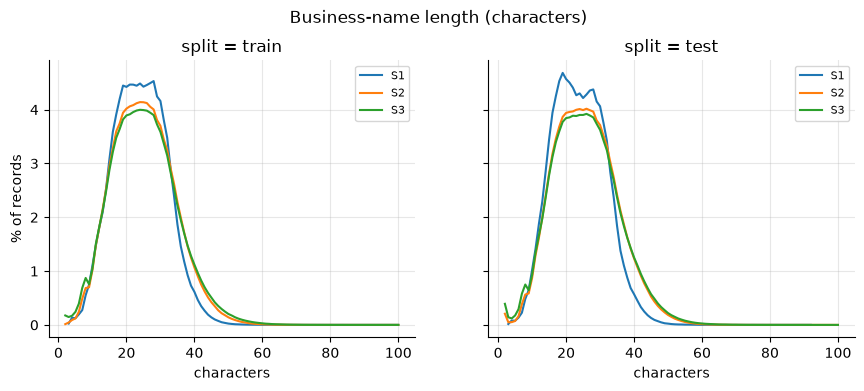

In [11]:
h_name_len = value_hist(scan_sources(), n_chars("business_name"), clip=100)
plot_hist_panels(h_name_len, "split", "source", "Business-name length (characters)", "characters", "02_name_length_by_source")

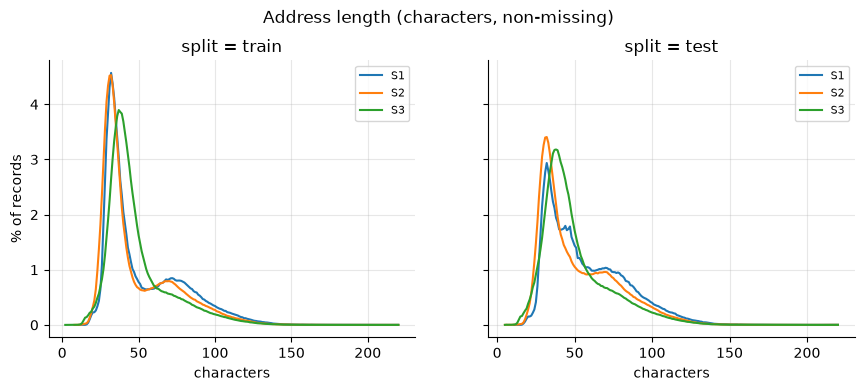

In [12]:
h_addr_len = value_hist(scan_sources().filter(pl.col("business_address").is_not_null()),
                        n_chars("business_address"), clip=220)
plot_hist_panels(h_addr_len, "split", "source", "Address length (characters, non-missing)", "characters", "02_address_length_by_source")

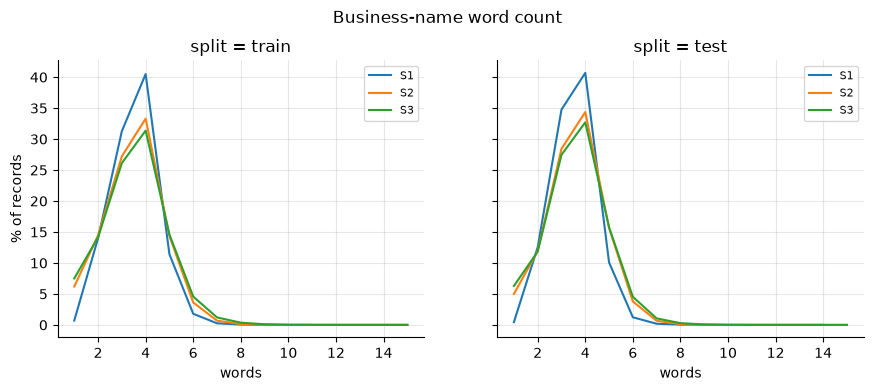

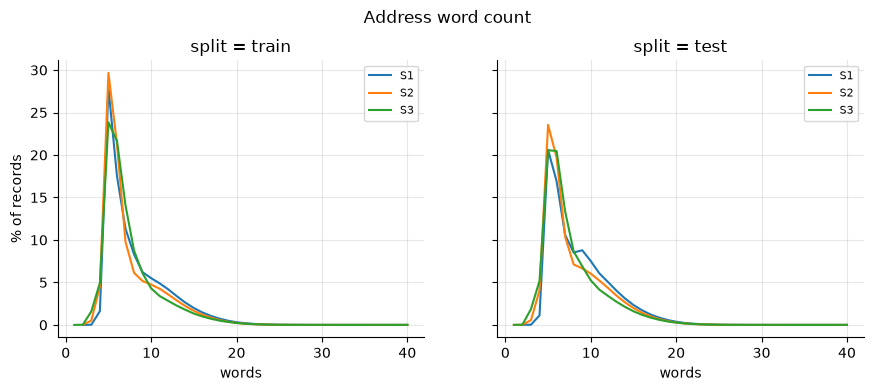

In [13]:
h_name_w = value_hist(scan_sources(), n_words("business_name"), clip=15)
h_addr_w = value_hist(scan_sources().filter(pl.col("business_address").is_not_null()), n_words("business_address"), clip=40)
plot_hist_panels(h_name_w, "split", "source", "Business-name word count", "words", "02_name_words_by_source")
plot_hist_panels(h_addr_w, "split", "source", "Address word count", "words", "02_address_words_by_source")

**Interpretation.** The name-length and word-count distributions of S1, S2 and S3 nearly coincide. Noise in S2/S3 rarely changes length much: it rewrites characters, casing and token order rather than adding or removing large chunks. Address lengths are wider and multi-modal because they mix countries (US addresses are short and India addresses long; see §8). S2 addresses are slightly shorter than S1 addresses (median 37 vs 41), consistent with dropped components.

### 2.3 Duplicate values within each file (exact raw strings, full data)

In [14]:
def duplicate_stats(key: pl.Expr, label: str) -> pl.DataFrame:
    '''For each file: how many rows share their key with at least one other row, and the group-size profile.'''
    out = []
    for sp, s in SOURCE_FILES:
        g = collect(scan_source(sp, s).select(key.alias("k")).drop_nulls().group_by("k").len("n"))
        out.append(g.select(
            split=pl.lit(sp), source=pl.lit(s), key=pl.lit(label),
            non_null_rows=pl.col("n").sum(), distinct=pl.len(),
            repeated_values=(pl.col("n") > 1).sum(),
            rows_in_repeated=pl.col("n").filter(pl.col("n") > 1).sum(),
            max_group=pl.col("n").max(),
        ).with_columns(pct_rows_in_repeated=(pl.col("rows_in_repeated") / pl.col("non_null_rows") * 100).round(2)))
    return pl.concat(out)


dups_raw = save_table(pl.concat([duplicate_stats(pl.col("business_name"), "name"),
                                 duplicate_stats(pl.col("business_address"), "address"),
                                 duplicate_stats(pl.concat_str("business_name", "business_address", separator=" | "), "name+address")]),
                      "02_duplicates_raw")
dups_raw

split,source,key,non_null_rows,distinct,repeated_values,rows_in_repeated,max_group,pct_rows_in_repeated
str,str,str,u32,u32,u32,u32,u32,f64
"""train""","""S1""","""name""",2206821,1539229,177793,845385,253,38.31
"""train""","""S2""","""name""",5034616,4402009,239779,872386,320,17.33
"""train""","""S3""","""name""",5285603,4651609,258276,892270,421,16.88
"""test""","""S1""","""name""",1732544,1238867,129955,623632,205,36.0
"""test""","""S2""","""name""",4887273,4311041,223103,799335,302,16.36
"""test""","""S3""","""name""",5082316,4521929,238156,798543,387,15.71
"""train""","""S1""","""address""",2206821,2130606,40089,116304,14,5.27
"""train""","""S2""","""address""",4865649,4337261,421472,949860,18,19.52
"""train""","""S3""","""address""",5109687,4632764,382890,859813,29,16.83


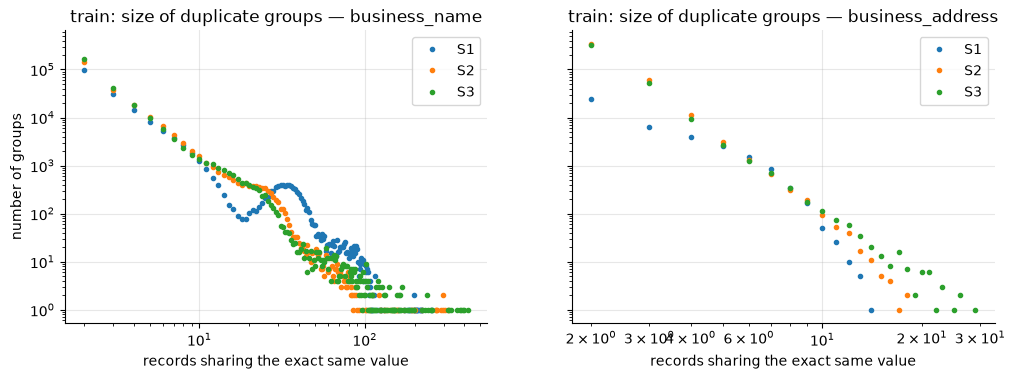

In [15]:
def group_size_distribution(split: str, source: str, col: str) -> pl.DataFrame:
    g = collect(scan_source(split, source).select(pl.col(col).alias("k")).drop_nulls().group_by("k").len("n"))
    return g.group_by("n").len("groups").with_columns(split=pl.lit(split), source=pl.lit(source), col=pl.lit(col))


gsd = pl.concat([group_size_distribution("train", s, c) for s in SOURCES for c in TEXT_COLS])
save_table(gsd.sort("col", "source", "n"), "02_duplicate_group_sizes_train")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, c in zip(axes, TEXT_COLS):
    for s in SOURCES:
        d = gsd.filter((pl.col("col") == c) & (pl.col("source") == s) & (pl.col("n") > 1)).sort("n")
        ax.loglog(d["n"], d["groups"], marker=".", ls="none", label=s)
    ax.set_title(f"train: size of duplicate groups — {c}")
    ax.set_xlabel("records sharing the exact same value")
    ax.legend()
axes[0].set_ylabel("number of groups")
save_fig(fig, "02_duplicate_group_sizes")

In [16]:
top_dup_names = pl.concat([
    collect(scan_source(sp, "S1").group_by("business_name").len("n").sort("n", descending=True).head(8)).with_columns(split=pl.lit(sp))
    for sp in SPLITS])
top_dup_names

business_name,n,split
str,u32,str
"""Primary Care Group""",253,"""train"""
"""Ear Nose & Throat Group""",251,"""train"""
"""Pediatric Group""",222,"""train"""
"""Womens Health Group""",220,"""train"""
"""Physical Therapy Group""",218,"""train"""
"""Pediatric Dental Group""",216,"""train"""
"""Behavioral Health Group""",215,"""train"""
"""Chiropractic Group""",209,"""train"""
"""Bordeaux Club SARL""",205,"""test"""


**Interpretation.** Repeated **names are common, even in the de-duplicated S1**: 38 % of train S1 rows share their exact name with at least one other S1 row, and generic names like *Primary Care Group* occur 253 times. By contrast, **name + address is never repeated in S1**, so S1 is de-duplicated on the (name, address) pair, not on the name. Exact duplicate addresses are rare in S1 (5 %) but common in S2/S3 (17–21 %). The test top-list is dominated by templated French names (*Bordeaux Club SARL* ×205), so France brings its own heavy name collisions.

## 3. Business-name EDA

### 3.1 Noise indicators (% of names, full data)

In [17]:
name_flags = text_flags("business_name")
name_flag_rates = save_table(flag_rates(scan_sources(), "business_name", name_flags), "03_name_flags_by_source")
name_flag_rates

split,source,rows,has_digit,has_punct,has_ampersand,url_or_domain,non_ascii,latin_diacritics,non_latin_script,all_upper,all_lower,repeated_space,lead_trail_space,odd_symbols,replacement_char
str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""S1""",2206821,1.61,20.92,5.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.09,0.0
"""train""","""S2""",5034616,5.08,34.77,4.15,4.0,15.19,5.77,9.42,18.9,5.75,11.01,0.0,4.78,0.0
"""train""","""S3""",5285603,5.12,35.54,4.1,3.99,11.48,6.21,5.27,2.96,6.25,10.89,0.0,4.95,0.0
"""test""","""S1""",1732544,1.17,18.32,5.02,0.0,2.35,2.35,0.0,0.0,0.0,0.0,0.0,0.06,0.0
"""test""","""S2""",4887273,3.89,31.34,4.27,3.19,18.99,7.81,11.18,17.49,5.03,10.24,0.0,4.03,0.0
"""test""","""S3""",5082316,3.98,31.94,4.19,3.23,14.51,8.2,6.31,3.2,5.53,10.22,0.0,4.25,0.0


In [18]:
name_flags_country = save_table(flag_rates(scan_sources(), "business_name", name_flags, by=("split", "country")),
                                "03_name_flags_by_country")
name_flags_country

split,country,rows,has_digit,has_punct,has_ampersand,url_or_domain,non_ascii,latin_diacritics,non_latin_script,all_upper,all_lower,repeated_space,lead_trail_space,odd_symbols,replacement_char
str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""India""",5016534,2.69,25.8,3.49,2.9,19.01,4.0,15.01,7.1,3.96,8.48,0.0,3.56,0.0
"""train""","""US""",7510506,5.69,37.24,4.83,3.55,5.56,5.56,0.0,10.01,5.61,9.38,0.0,4.34,0.0
"""test""","""France""",1694445,1.06,26.74,5.81,2.93,22.93,22.93,0.0,11.06,5.55,7.21,0.0,1.92,0.0
"""test""","""India""",5527551,2.6,25.16,3.48,2.44,19.48,3.79,15.69,6.98,3.59,8.56,0.0,3.47,0.0
"""test""","""US""",4480137,5.6,36.35,4.86,3.03,5.39,5.39,0.0,9.92,5.23,9.47,0.0,4.24,0.0


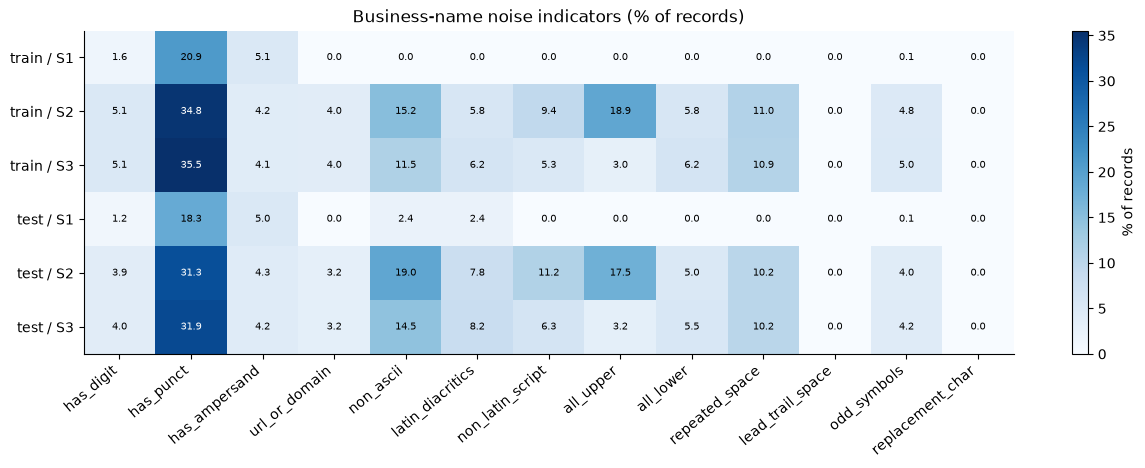

In [19]:
def plot_flag_heatmap(df: pl.DataFrame, id_cols, title, fname):
    flag_cols = [c for c in df.columns if c not in (*id_cols, "rows")]
    labels = [" / ".join(str(r[c]) for c in id_cols) for r in df.iter_rows(named=True)]
    m = df.select(flag_cols).to_numpy().astype(float)
    fig, ax = plt.subplots(figsize=(1.0 * len(flag_cols) + 2, 0.45 * len(labels) + 1.5))
    im = ax.imshow(m, cmap="Blues", aspect="auto", vmin=0, vmax=max(20, np.nanmax(m)))
    ax.set_xticks(range(len(flag_cols)), flag_cols, rotation=40, ha="right")
    ax.set_yticks(range(len(labels)), labels)
    ax.grid(False)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            ax.text(j, i, f"{m[i, j]:.1f}", ha="center", va="center", fontsize=7,
                    color="white" if m[i, j] > 0.6 * ax.images[0].norm.vmax else "black")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="% of records")
    save_fig(fig, fname)


plot_flag_heatmap(name_flag_rates, ("split", "source"), "Business-name noise indicators (% of records)", "03_name_flags_heatmap")

**Interpretation.** S1 names are clean: no non-ASCII characters in train, no casing anomalies, no double spaces and no URLs. **S2 and S3 carry the noise**, and each source has its own profile:

* Punctuation variation in about ⅓ of names, and repeated spaces in ≈11 %.
* S2 is **all upper-case** in ≈18 % of names, versus ≈3 % for S3.
* Non-Latin script appears in 9–11 % of S2 names and 5–6 % of S3 names. By country this is ≈15 % of Indian names.
* 4 % of names are domain names (`xyz.com`).
* ≈5 % contain odd symbols (`[ ]`, `*`, `#`).
* Latin diacritics appear in 5–8 % of names. Outside France they are injected typos (*Sólar*, *Cáre*).
* No Unicode replacement characters occurred, so the files are clean UTF-8.

### 3.2 Real examples of noisy names (hash sample of train, 3 per source)

In [20]:
show_flags = ["url_or_domain", "non_latin_script", "latin_diacritics", "all_upper", "all_lower",
              "repeated_space", "odd_symbols", "has_digit", "replacement_char"]
name_examples = flag_examples("business_name", {k: name_flags[k] for k in show_flags}, n=2)
save_table(name_examples, "03_name_noise_examples")
name_examples

pattern,entity_id,country,business_name
str,str,str,str
"""url_or_domain""","""S2-89371166""","""India""","""dineshindiaagency.com"""
"""url_or_domain""","""S2-542732821""","""US""","""apexcrest.com"""
"""url_or_domain""","""S3-976003929""","""US""","""doralynlackeyrobinhood.com"""
"""url_or_domain""","""S3-499111004""","""US""","""maidpizza.com"""
"""non_latin_script""","""S2-414010221""","""India""","""વિજય કન્સ્ટ્રક્શન્સ"""
"""non_latin_script""","""S2-999759387""","""India""","""हाई प्रॉपर्टीज प्राइवेट लिमिटेड"""
"""non_latin_script""","""S3-987949855""","""India""","""Southern பவர்"""
"""non_latin_script""","""S3-575525905""","""India""","""शिवा यूनाइटेड इंडस्ट्रीज प्राइवेट लिमिटेड"""
"""latin_diacritics""","""S2-978126813""","""India""","""Private Ambernath Sólar Limited"""


**Interpretation.** These are all real records. They show the kinds of name noise to expect: websites standing in for names (`dineshindiaagency.com`), fully transliterated names, mixed-script names (`Southern பவர்`), fake accents, collapsed/extra whitespace, legal forms moved to the front and bracketed (`[Llc] East Hea1th Center`), and **digit-for-letter typos** (`Leopo1d`, `Hea1th`). Phone-number-like suffixes also appear (`- 7934786696`).

### 3.3 Scripts used in names (full data, counts of records)

In [21]:
def script_counts(col: str) -> pl.DataFrame:
    df = collect(scan_sources().group_by("split", "source", "country").agg(
        pl.len().alias("rows"), *[pl.col(col).str.contains(rf"\p{{{sc}}}").sum().alias(sc) for sc in SCRIPTS]))
    keep = [sc for sc in SCRIPTS if df[sc].sum() > 0]
    return order(df.select("split", "source", "country", "rows", *keep))


name_scripts = save_table(script_counts("business_name"), "03_name_scripts")
name_scripts

split,source,country,rows,Devanagari,Bengali,Gurmukhi,Gujarati,Oriya,Tamil,Telugu,Kannada,Malayalam
str,str,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""train""","""S1""","""India""",883188,0,0,0,0,0,0,0,0,0
"""train""","""S1""","""US""",1323633,0,0,0,0,0,0,0,0,0
"""train""","""S2""","""India""",2017799,269424,30723,6688,30929,7493,33781,39323,37211,18773
"""train""","""S2""","""US""",3016817,0,0,0,0,0,0,0,0,0
"""train""","""S3""","""India""",2115547,158003,18144,4106,18020,4317,19790,23033,21995,11116
"""train""","""S3""","""US""",3170056,0,0,0,0,0,0,0,0,0
"""test""","""S1""","""France""",259452,0,0,0,0,0,0,0,0,0
"""test""","""S1""","""India""",809986,0,0,0,0,0,0,0,0,0
"""test""","""S1""","""US""",663106,0,0,0,0,0,0,0,0,0


In [22]:
script_examples = pl.concat([
    collect(hash_sample(scan_sources(["train"], ["S2", "S3"]), 5)
            .filter(pl.col("business_name").str.contains(rf"\p{{{sc}}}"))
            .select(pl.lit(sc).alias("script"), "entity_id", "business_name", "business_address").head(2))
    for sc in [c for c in name_scripts.columns if c in SCRIPTS]])
script_examples

script,entity_id,business_name,business_address
str,str,str,str
"""Devanagari""","""S2-429779755""","""ईस्टर्न इन्वेस्टमेंट प्राइवेट लिमिटेड""","""GURGAON, ESPACE, NIRWANA COUNTRY SECTOR - 50, NR GOLF COURSE ROAD, GURGAON, हरियाणा, HN 32 H. NO. - …"
"""Devanagari""","""S2-999759387""","""हाई प्रॉपर्टीज प्राइवेट लिमिटेड""","""H.NO C-555 ROOM 2, GOREGAON EAST, MUMBAI, Maharashtra"""
"""Bengali""","""S2-886423991""","""ওয়ান অ্যাগ্রো প্রাইভেট লিমিটেড""","""21/1 RADHANATH CHWDHURY ROAD, KOLKATA, CALCUTTA, West Bengal"""
"""Bengali""","""S2-558685848""","""আনন্দ সিস্টেমস""","""WEBEL BHAVAN BLOCK EP&GP SALT LAKE BIDHANNAGAR, KOLKATA, NORTH 24 PARGANAS, West Bengal"""
"""Gurmukhi""","""S2-9166592""","""ਤਿਰੂਪਤੀ ੴ ਬਿਜ਼ਨਸ ਪ੍ਰਾਈਵੇਟ ਲਿਮਟਿਡ""","""DOOR NO 2ND FLOOR SEC-8 ANEJA TOW, B-BLOCK RANJIT AVE., AMRITSAR, FATEHGARHSUKAR CHAK, Punjab"""
"""Gurmukhi""","""S2-988499930""","""ਕਲਾਸਿਕ ਡਿਵੈਲਪਰਜ਼ ਪ੍ਰਾਈਵੇਟ ਲਿਮਟਿਡ""","""C/O GAGANDEEP SINGH GORAYA VILLAGE THIKRIWALA, GURDASPUR, Punjab"""
"""Gujarati""","""S2-414010221""","""વિજય કન્સ્ટ્રક્શન્સ""","""ADITYA PLAZA. NR. KARNAVATI APPARTMENTS., JODHPUR, SATELLITE, AHEMEDABAD, 310, ગુજરાત"""
"""Gujarati""","""S2-353212181""","""રોયલ રામ ગ્લોબલ પ્રા. લિ.""","""531, SURAT, Gujarat"""
"""Oriya""","""S2-193378620""","""ବ୍ଲୁ ହସ୍ପିଟାଲିଟି ପ୍ରାଇଭେଟ୍ ଲିମିଟେଡ୍""","""PLOT NO-0018/2492/2497, 29-G-282/000, KHANDAGIRI, BHUBANESWAR, KHORDHA, ଓଡ଼ିଶା"""


**Interpretation.** Non-Latin scripts occur **only in Indian records of S2/S3**, never in S1 and never in US or France records. Devanagari dominates (≈270 k train S2 names), followed by Telugu, Kannada, Tamil, Gujarati and Bengali. The examples show that these are **transliterations of the English S1 name** (e.g. `प्राइवेट लिमिटेड` = *Private Limited*), so token overlap with the Latin S1 name is zero.

### 3.4 Legal suffixes / company forms (on conservatively normalised names, full data)

In [23]:
LEGAL_FORMS = {
    "llc": r"\bl ?l ?c\b", "inc": r"\binc\b", "incorporated": r"\bincorporated\b",
    "corp": r"\bcorp\b", "corporation": r"\bcorporation\b", "co": r"\bco\b", "company": r"\bcompany\b",
    "ltd": r"\bltd\b", "limited": r"\blimited\b", "pvt": r"\bpvt\b", "private": r"\bprivate\b",
    "llp": r"\bllp\b", "lp": r"\blp\b", "pllc": r"\bpllc\b", "plc": r"\bplc\b",
    "sarl": r"\bs ?a ?r ?l\b", "sas/sasu": r"\bsasu?\b", "sa": r"\bsa\b", "eurl": r"\beurl\b",
    "sci": r"\bsci\b", "snc": r"\bsnc\b", "gmbh": r"\bgmbh\b",
    "dba/aka": r"\b(dba|d b a|aka|trading as)\b",
    "limited/private (Devanagari)": r"लिमिटेड|प्राइवेट",
}
LEGAL_ANY = "|".join(f"(?:{p})" for p in LEGAL_FORMS.values())

nn = normalize_expr("business_name")
legal = order(collect(scan_sources().group_by("split", "country", "source").agg(
    pl.len().alias("rows"),
    (nn.str.contains(LEGAL_ANY).mean() * 100).round(2).alias("ANY_legal_form"),
    (nn.str.contains(rf"^(?:{LEGAL_ANY})\b").mean() * 100).round(2).alias("legal_form_at_START"),
    *[(nn.str.contains(p).mean() * 100).round(2).alias(k) for k, p in LEGAL_FORMS.items()])))
save_table(legal, "03_legal_forms")
legal

split,country,source,rows,ANY_legal_form,legal_form_at_START,llc,inc,incorporated,corp,corporation,co,company,ltd,limited,pvt,private,llp,lp,pllc,plc,sarl,sas/sasu,sa,eurl,sci,snc,gmbh,dba/aka,limited/private (Devanagari)
str,str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""India""","""S1""",883188,84.29,0.04,0.0,0.0,0.0,0.77,0.79,2.18,0.78,16.52,59.08,13.75,48.91,4.38,0.01,0.0,0.0,0.0,0.01,0.02,0.0,0.0,0.0,0.0,0.0,0.0
"""train""","""US""","""S1""",1323633,53.28,0.01,28.53,18.0,0.0,2.11,0.56,0.63,0.52,0.2,0.04,0.0,0.03,0.08,1.25,1.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""train""","""India""","""S2""",2017799,66.47,4.18,0.0,0.0,0.0,0.99,1.02,2.05,1.02,15.21,26.14,9.38,26.14,3.14,0.01,0.0,0.0,0.0,0.01,0.02,0.0,0.0,0.0,0.0,0.0,9.42
"""train""","""US""","""S2""",3016817,48.3,3.37,19.85,13.27,0.87,4.04,1.39,3.26,0.37,3.03,0.04,0.0,0.02,0.04,1.59,0.77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""train""","""India""","""S3""",2115547,69.22,4.69,0.0,0.0,0.0,0.94,0.97,2.11,0.96,16.14,31.77,10.42,30.21,3.58,0.01,0.0,0.0,0.0,0.01,0.02,0.0,0.0,0.0,0.0,1.13,5.04
"""train""","""US""","""S3""",3170056,48.05,3.2,20.11,13.25,0.69,3.8,1.19,3.13,0.37,2.72,0.04,0.0,0.02,0.04,1.44,0.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.56,0.0
"""test""","""France""","""S1""",259452,67.31,0.06,0.0,0.0,0.0,0.0,0.01,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,28.32,24.28,4.92,6.54,3.22,0.0,0.0,0.0,0.0
"""test""","""India""","""S1""",809986,84.26,0.04,0.0,0.0,0.0,0.78,0.83,2.18,0.76,16.46,59.06,13.69,48.93,4.38,0.01,0.0,0.0,0.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,0.0
"""test""","""US""","""S1""",663106,53.24,0.01,28.51,17.98,0.0,2.1,0.56,0.63,0.52,0.2,0.04,0.0,0.04,0.08,1.26,1.54,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
legal_examples = collect(hash_sample(scan_sources(["train", "test"], ["S2", "S3"]), 2)
                         .filter(normalize_expr("business_name").str.contains(rf"^(?:{LEGAL_ANY})\b"))
                         .group_by("country").head(4)
                         .select("entity_id", "country", "business_name"))
legal_examples

entity_id,country,business_name
str,str,str
"""S2-801612886""","""US""","""LLC Buus"""
"""S2-540205713""","""US""","""LLC QSI"""
"""S2-237430320""","""US""","""Inc. Granite"""
"""S2-7757866""","""US""","""LLC TOTAL AGRICULTURAL INDUSTRIES"""
"""S2-978126813""","""India""","""Private Ambernath Sólar Limited"""
"""S2-307272578""","""India""","""PRIVATE PRERNA (LNDIA) SYSTEMS LIMITED"""
"""S2-105291052""","""India""","""LLP RAM ENTERPRISES AGENCIES"""
"""S2-65811919""","""India""","""Private SW Infraserv Limited"""
"""S2-291128500""","""France""","""SARL RECHERCHE ÈCOLE"""


**Interpretation.** Legal forms are frequent and country-specific: US *LLC/Inc*; India *Private/Limited/Pvt/Ltd/LLP*; France *SARL/SAS/SASU/EURL/SCI/SA*.

* S1 prefers long forms. Indian S1 names use *limited* 59 % of the time and *ltd* 16.5 %. S2/S3 shift towards abbreviations (limited 26–33 %).
* In Indian S2/S3 names, 5–9 % carry the legal form in Devanagari.
* S1 almost never puts the legal form first (0.01–0.06 %), but **3–5 % of S2/S3 names start with it** (`LLC Buus`, `Private SW Infraserv Limited`, `SARL RECHERCHE ÈCOLE`).

Legal forms are therefore both noisy and weakly informative, which is why this EDA does not strip them.

## 4. Address EDA

### 4.1 Generic noise indicators (% of non-missing addresses, full data)

In [25]:
addr_flags = text_flags("business_address")
addr_flag_rates = save_table(flag_rates(scan_sources(), "business_address", addr_flags), "04_address_flags_by_source")
addr_flag_rates

split,source,rows,has_digit,has_punct,has_ampersand,url_or_domain,non_ascii,latin_diacritics,non_latin_script,all_upper,all_lower,repeated_space,lead_trail_space,odd_symbols,replacement_char
str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""S1""",2206821,96.51,100.0,0.88,0.0,0.03,0.03,0.0,0.0,0.0,0.04,0.0,0.79,0.0
"""train""","""S2""",4865649,93.79,100.0,0.84,0.0,9.83,0.02,9.81,65.58,0.0,2.21,0.0,8.7,0.0
"""train""","""S3""",5109687,93.93,100.0,0.72,0.0,9.33,0.02,9.31,0.02,0.0,0.1,0.0,11.44,0.0
"""test""","""S1""",1732544,95.85,100.0,1.04,0.0,4.26,4.2,0.0,0.0,0.0,0.04,0.0,0.8,0.0
"""test""","""S2""",4757865,95.19,100.0,0.99,0.0,15.15,2.91,11.57,51.54,0.0,1.74,0.0,8.93,0.0
"""test""","""S3""",4946218,95.04,100.0,0.86,0.0,14.74,2.97,11.13,0.02,0.0,0.06,0.0,10.6,0.0


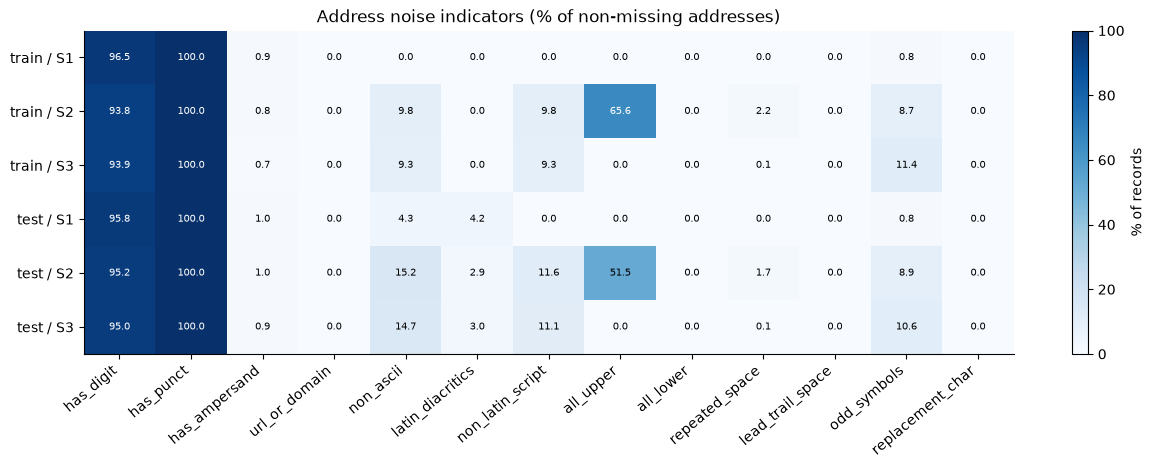

In [26]:
plot_flag_heatmap(addr_flag_rates, ("split", "source"), "Address noise indicators (% of non-missing addresses)", "04_address_flags_heatmap")

**Interpretation.** Nearly all addresses contain digits (94–97 %) and punctuation (100 %, since commas separate components). The sources differ in systematic ways:

* **S2 addresses are upper-case in 52–66 % of records**, versus ≈0 % for S1/S3.
* ≈10–12 % of S2/S3 addresses contain non-Latin script (Indian state names such as `महाराष्ट्र`).
* S2/S3 carry odd symbols (`#`, `##`, `<NULL>`) in 9–11 % of addresses, versus <1 % for S1.
* S1 addresses gain diacritics only in test, from French records.

### 4.2 Missing addresses by country (full data)

In [27]:
addr_missing = order(collect(scan_sources().group_by("split", "source", "country").agg(
    pl.len().alias("rows"), (pl.col("business_address").is_null().mean() * 100).round(2).alias("pct_missing_address"))))
save_table(addr_missing, "04_address_missing_by_country")
addr_missing.pivot(on="country", index=["split", "source"], values="pct_missing_address")

split,source,India,US,France
str,str,f64,f64,f64
"""train""","""S1""",0.0,0.0,null
"""train""","""S2""",2.87,3.68,null
"""train""","""S3""",3.07,3.5,null
"""test""","""S1""",0.0,0.0,0.0
"""test""","""S2""",2.28,2.94,3.06
"""test""","""S3""",2.46,2.84,2.94


**Interpretation.** Missing addresses only occur in S2/S3, at 2.3–3.7 % for every country. The rate is slightly lower in test than in train. For these records only the name (and country) can decide a match.

### 4.3 Address structure: landmarks, care-of, house numbers, postcodes, component order (full data)

In [28]:
a = pl.col("business_address")
starts_num = a.str.contains(r"^\s*#*\s*\d")
ADDR_PATTERNS = {
    "landmark (near/opp/behind...)": a.str.contains(r"(?i)\b(near|nr|opp|opposite|behind|beside|next to|adjacent to|in front of|landmark)\b"),
    "care-of (c/o s/o w/o d/o)": a.str.contains(r"(?i)\b[cswd]\s?/\s?o\b"),
    "hash '#' symbol": a.str.contains("#", literal=True),
    "starts with house number": starts_num,
    "house no. only in later segment": (~starts_num) & a.str.contains(r",\s*#*\d+[A-Za-z]?\s+\p{L}"),
    "starts with 2-letter code ('MA, ...')": a.str.contains(r"^[A-Z]{2}\s*,"),
    "ends with 2-letter code (', TX')": a.str.contains(r",\s*[A-Z]{2}\s*$"),
    "5-digit token": a.str.contains(r"\b\d{5}\b"),
    "6-digit token (PIN-like)": a.str.contains(r"\b\d{6}\b|\b\d{3}\s\d{3}\b"),
    "PO box": a.str.contains(r"(?i)\bp\.?\s?o\.?\s?box\b"),
    "unit/suite/apt/floor": a.str.contains(r"(?i)\b(suite|ste|apt|unit|flat|floor|fl)\b"),
    "plot/khasra/survey/house no": a.str.contains(r"(?i)\b(plot|kh|khasra|survey|sy|h\.?\s?no|house no)\b"),
}
addr_struct = order(collect(scan_sources().filter(a.is_not_null()).group_by("split", "country", "source").agg(
    pl.len().alias("rows"),
    (a.str.count_matches(",") + 1).mean().round(2).alias("mean_comma_segments"),
    *[(e.mean() * 100).round(2).alias(k) for k, e in ADDR_PATTERNS.items()])))
save_table(addr_struct, "04_address_structure")
addr_struct

split,country,source,rows,mean_comma_segments,landmark (near/opp/behind...),care-of (c/o s/o w/o d/o),hash '#' symbol,starts with house number,house no. only in later segment,"starts with 2-letter code ('MA, ...')","ends with 2-letter code (', TX')",5-digit token,6-digit token (PIN-like),PO box,unit/suite/apt/floor,plot/khasra/survey/house no
str,str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""train""","""India""","""S1""",883188,5.66,13.6,6.13,1.36,26.63,2.37,0.0,0.0,0.27,0.33,0.0,24.67,17.31
"""train""","""US""","""S1""",1323633,3.16,0.01,0.0,0.35,85.97,11.9,6.39,86.39,10.82,0.57,0.0,15.43,0.0
"""train""","""India""","""S2""",1959953,4.98,11.97,6.1,11.44,24.44,1.99,0.03,0.01,1.1,1.15,0.0,21.64,19.82
"""train""","""US""","""S2""",2905696,3.07,0.01,0.0,5.42,80.41,9.76,6.55,86.52,10.52,1.8,1.73,0.1,0.0
"""train""","""India""","""S3""",2050599,4.85,9.1,6.04,10.78,23.79,1.8,3.26,58.94,1.03,1.1,0.0,17.93,18.17
"""train""","""US""","""S3""",3059088,3.19,0.01,0.0,10.53,80.62,9.91,0.31,4.26,10.54,1.75,1.63,7.88,0.0
"""test""","""France""","""S1""",259452,3.04,0.0,0.0,0.0,86.01,13.37,0.0,0.0,0.39,0.02,0.0,0.14,0.0
"""test""","""India""","""S1""",809986,5.66,13.58,6.16,1.36,26.55,2.37,0.0,0.0,0.26,0.34,0.0,24.61,17.3
"""test""","""US""","""S1""",663106,3.16,0.01,0.0,0.34,86.01,11.86,6.42,86.36,10.82,0.56,0.0,15.41,0.0


In [29]:
addr_struct_examples = flag_examples("business_address", {k: ADDR_PATTERNS[k] for k in [
    "landmark (near/opp/behind...)", "care-of (c/o s/o w/o d/o)", "house no. only in later segment",
    "starts with 2-letter code ('MA, ...')", "hash '#' symbol"]}, n=2)
save_table(addr_struct_examples, "04_address_pattern_examples")
addr_struct_examples

pattern,entity_id,country,business_address
str,str,str,str
"""landmark (near/opp/behind...)""","""S1-505869859""","""India""","""Ff-104, Meera Mana Arcade, Beside Krupa Petrol Pump, Ellisbridge, Ahmedabad, Gujarat"""
"""landmark (near/opp/behind...)""","""S1-187058094""","""India""","""Indochem House 8 Sundarvansociety Opp Gujarat Vidyapith Ushmanpura Ashram Road, Gujarat, Ahmedabad"""
"""landmark (near/opp/behind...)""","""S2-414010221""","""India""","""ADITYA PLAZA. NR. KARNAVATI APPARTMENTS., JODHPUR, SATELLITE, AHEMEDABAD, 310, ગુજરાત"""
"""landmark (near/opp/behind...)""","""S2-913017158""","""India""","""ગુજરાત, DOOR NO 115 ARCHER HOUSE, OPP.AGETA, GURUKUL ROAD, AHMADABAD CITY"""
"""landmark (near/opp/behind...)""","""S3-130163447""","""India""","""C/o Opp. Bhankhariya Bus, Stand, 1St Floor, Prantij, Himatnagar, ગુજરાત"""
"""landmark (near/opp/behind...)""","""S3-878325319""","""India""","""Opposite Gujarat Metal Cast Village Dunia, Halol Godhra Road, Halol, Panchmahal, Gujarat"""
"""care-of (c/o s/o w/o d/o)""","""S1-982210261""","""India""","""C/O Dwarkadhis Enterprise, C.M. Palace, Ist Floor, Shop 3, Vill: Gondal(Mog), Gondal, Rajkot, Gondal…"
"""care-of (c/o s/o w/o d/o)""","""S1-315325465""","""India""","""Sri Arbind Kumar S/O Sri Shiv Narayan Rai Mahabir Nagar 70 Fit Road Gardanbagh, Patna, Bihar"""
"""care-of (c/o s/o w/o d/o)""","""S2-460515872""","""India""","""Haryana, C/O TULSI RAM, FATEHABAD"""


**Interpretation.** Component order and format vary by source and country:

* **US:** ≈86 % of S1 addresses start with a house number, but ≈10–12 % have the house number only in a later segment (`OH, Columbus, 507 Evergreen Terrace`). About 6.5 % start with a state code. S1/S2 end with a 2-letter state code 86 % of the time, but **S3 uses full state names** (only 4 % end with a code).
* **India:** long, landmark-rich addresses (≈5.7 segments). *Near/opp/behind* landmarks appear in 9–14 %, **care-of (C/o, S/o, W/o)** in ≈6 %, plot/khasra/house-no. markers in ≈18 %, and units/floors in ≈20 %. S3 abbreviates Indian states (59 % end with a 2-letter code such as `MH` or `UP`), while S1 never does. Only ≈25 % start with a number.
* **France:** short (≈2.7–3 segments), with a number first in 72–86 %.
* Postcodes are rare everywhere (5-digit tokens ≈10 % in the US, 6-digit PINs ≈1 % in India), so they cannot serve as a reliable key.

### 4.4 Abbreviated vs full forms of common address words (on normalised addresses, full data)

In [30]:
ADDR_TERMS = [("street", r"\bstreet\b", r"\bst\b"), ("road", r"\broad\b", r"\brd\b"),
              ("avenue", r"\bavenue\b", r"\bave?\b"), ("drive", r"\bdrive\b", r"\bdr\b"),
              ("boulevard", r"\bboulevard\b", r"\bblvd\b"), ("lane", r"\blane\b", r"\bln\b"),
              ("suite", r"\bsuite\b", r"\bste\b"), ("apartment", r"\bapartment\b", r"\bapt\b"),
              ("building", r"\bbuilding\b", r"\bbldg\b"), ("near", r"\bnear\b", r"\bnr\b"),
              ("opposite", r"\bopposite\b", r"\bopp\b"), ("number", r"\bnumber\b", r"\bno\b"),
              ("district", r"\bdistrict\b", r"\bdist\b"), ("rue (FR)", r"\brue\b", r"\br\b"),
              ("boulevard (FR bd)", r"\bboulevard\b", r"\bbd\b")]
na = normalize_expr("business_address")
abbr = collect(scan_sources().filter(a.is_not_null()).group_by("country", "source").agg(
    *[(na.str.contains(p).mean() * 100).round(2).alias(f"{t}|full") for t, p, _ in ADDR_TERMS],
    *[(na.str.contains(p).mean() * 100).round(2).alias(f"{t}|abbr") for t, _, p in ADDR_TERMS]))
abbr_long = (abbr.unpivot(index=["country", "source"], variable_name="term_form", value_name="pct")
             .with_columns(pl.col("term_form").str.split_exact("|", 1).struct.rename_fields(["term", "form"])).unnest("term_form")
             .with_columns(col=pl.col("country") + "-" + pl.col("source")))
abbr_wide = abbr_long.pivot(on="col", index=["term", "form"], values="pct")
abbr_wide = abbr_wide.select("term", "form", *sorted(c for c in abbr_wide.columns if c not in ("term", "form")))
save_table(abbr_wide, "04_address_abbreviations")
abbr_wide

term,form,France-S1,France-S2,France-S3,India-S1,India-S2,India-S3,US-S1,US-S2,US-S3
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""street""","""full""",0.0,0.0,0.0,4.07,3.61,2.82,20.66,9.17,9.73
"""road""","""full""",0.0,0.0,0.0,24.39,21.61,16.75,18.68,8.5,8.95
"""avenue""","""full""",11.94,6.74,6.98,0.91,0.81,0.64,13.69,6.1,6.45
"""drive""","""full""",0.0,0.0,0.0,0.08,0.07,0.06,16.69,7.4,7.84
"""boulevard""","""full""",3.59,2.06,2.1,0.02,0.02,0.02,1.63,0.73,0.77
"""lane""","""full""",0.0,0.0,0.0,1.51,1.35,1.06,7.14,3.17,3.36
"""suite""","""full""",0.0,0.0,0.0,0.17,0.16,0.13,0.21,0.0,0.17
"""apartment""","""full""",0.0,0.0,0.0,1.36,1.21,0.96,1.4,0.0,1.11
"""building""","""full""",0.0,0.0,0.0,2.52,2.28,1.85,0.05,0.0,0.12


**Interpretation.** **S1 writes street types in full; S2/S3 abbreviate them roughly half the time.** In US records, *street* drops from 20.7 % in S1 to ≈9.5 % in S2/S3 while *st* rises from 0.7 % to ≈10.7 %; *road/rd*, *drive/dr* and *avenue/ave* behave the same way. France shows the same pattern with *rue* → *r* (S1 66 % *rue*, 0 % *r*; S2/S3 ≈40 % *rue*, ≈26 % *r*). Indian addresses mostly abbreviate *number* as *no* in every source. Short tokens are ambiguous (*st* can mean Saint, *dr* Doctor, *r* a stray initial), so any later abbreviation expansion must be context-aware.

### 4.5 Most repeated exact addresses in S1 (full data)

In [31]:
top_dup_addr = pl.concat([
    collect(scan_source(sp, "S1").group_by("business_address", "country").len("n").sort("n", descending=True).head(6)).with_columns(split=pl.lit(sp))
    for sp in SPLITS])
top_dup_addr

business_address,country,n,split
str,str,u32,str
"""108 Norle Street, College Twp, PA""","""US""",14,"""train"""
"""104 Roadrunner Circle, Elephant Butte, NM""","""US""",13,"""train"""
"""55, Lavkush Vihar, Singhpur, Kachhar Bithoor Road, Kalyanpur, Kanpur Nagar, Uttar Pradesh""","""India""",13,"""train"""
"""43 Franklin Street, Delaware, OH""","""US""",13,"""train"""
"""218 Phillips Street, Storm Lake, IA""","""US""",13,"""train"""
"""1921 Willow Park Drive, Fort Worth, TX""","""US""",13,"""train"""
"""12 RUE Lyderic, Lille, Hauts-de-France""","""France""",99,"""test"""
"""27 RUE Jean Bart, Lille, Hauts-de-France""","""France""",85,"""test"""
"""30 RUE des Meuniers, Lille, Hauts-de-France""","""France""",72,"""test"""


**Interpretation.** In train S1 the most repeated full addresses occur only ≈13–14 times. They are ordinary street addresses shared by several distinct businesses, such as office buildings. In test, **French addresses repeat far more** (up to 99 times for `12 RUE Lyderic, Lille`), matching the templated French names. Address alone therefore cannot identify an entity, especially for France.

## 5. Conservative normalisation

`normalize_expr` (defined in the helpers) applies only: **NFKC Unicode normalisation → lowercase → drop apostrophes →
other punctuation to a space → collapse/strip whitespace**. It deliberately does **not** remove legal suffixes, stop-words,
street types or accents, and does not expand abbreviations. Below: what it does to real records, and how much it changes
uniqueness.

In [32]:
norm_demo = collect(hash_sample(scan_sources(["train", "test"], ["S2", "S3"]), 1)
                    .filter(pl.col("business_name").str.contains(r"[^\p{L}\p{N}\s]|\s{2,}|[A-Z]{3,}") )
                    .group_by("country").head(4)
                    .select("country", "business_name", normalize_expr("business_name").alias("name_norm"),
                            "business_address", normalize_expr("business_address").alias("address_norm")))
norm_demo

country,business_name,name_norm,business_address,address_norm
str,str,str,str,str
"""India""","""SOLUTIONS TOHSRET (INDIA) PRIVATE LIMITED""","""solutions tohsret india private limited""","""FLB3/102 GREENWOODS 1651 23STMAINROAD ANNANAGAR(W), CHENNAI, Tamil Nadu""","""flb3 102 greenwoods 1651 23stmainroad annanagar w chennai tamil nadu"""
"""India""","""Prism Institute""","""prism institute""",null,null
"""India""","""M/s Jyotsana Law Chambers Group""","""m s jyotsana law chambers group""","""TF-352, SIDDHARTH MAGNUM PLUS, TARSALI DANTESHWAR RING ROAD, VADODARA, ગુજરાત""","""tf 352 siddharth magnum plus tarsali danteshwar ring road vadodara ગુજરાત"""
"""India""","""dineshindiaagency.com""","""dineshindiaagency com""","""HOUSE OF ANITYA KUMAR MOHANTY, MOUZA ANGARGADIA, KHATA NO-1757/391/53, BALESHWAR SADAR, Orissa""","""house of anitya kumar mohanty mouza angargadia khata no 1757 391 53 baleshwar sadar orissa"""
"""US""","""SOUTHERN DIAMOND INC SERVICE""","""southern diamond inc service""","""58 APPLE HILL DRIVE, VILLAGE OF BLUE MOUNDS, WI""","""58 apple hill drive village of blue mounds wi"""
"""US""","""Lfsc Group""","""lfsc group""","""499 BOSTON ROAD, BILLERICA, MA""","""499 boston road billerica ma"""
"""US""","""Billups Empire""","""billups empire""","""111-12 133 ST, SOUTH OZONE PARK, NY""","""111 12 133 st south ozone park ny"""
"""US""","""The-Diamond Health Corporation""","""the diamond health corporation""","""001 MENOWA DR, DAEVILLE, AL""","""001 menowa dr daeville al"""
"""France""","""PATRICIA SPORTIVE SARL""","""patricia sportive sarl""","""8 RUE DE GIEANT, ETAGE 3 - APPARTEMENT 13, NANTES, Pays de la Loire""","""8 rue de gieant etage 3 appartement 13 nantes pays de la loire"""


In [33]:
def uniqueness_raw_vs_norm() -> pl.DataFrame:
    out = []
    for sp, s in SOURCE_FILES:
        r = collect(scan_source(sp, s).select(
            rows=pl.len(),
            name_raw=pl.col("business_name").n_unique(),
            name_norm=normalize_expr("business_name").n_unique(),
            addr_raw=pl.col("business_address").drop_nulls().n_unique(),
            addr_norm=normalize_expr("business_address").drop_nulls().n_unique(),
        )).with_columns(split=pl.lit(sp), source=pl.lit(s))
        out.append(r)
    df = pl.concat(out).with_columns(
        name_pct_collapsed=((1 - pl.col("name_norm") / pl.col("name_raw")) * 100).round(2),
        addr_pct_collapsed=((1 - pl.col("addr_norm") / pl.col("addr_raw")) * 100).round(2))
    return order(df.select("split", "source", "rows", "name_raw", "name_norm", "name_pct_collapsed",
                           "addr_raw", "addr_norm", "addr_pct_collapsed"))


uniq = save_table(uniqueness_raw_vs_norm(), "05_uniqueness_raw_vs_normalized")
uniq

split,source,rows,name_raw,name_norm,name_pct_collapsed,addr_raw,addr_norm,addr_pct_collapsed
str,str,u32,u32,u32,f64,u32,u32,f64
"""train""","""S1""",2206821,1539229,1522207,1.11,2130606,2130167,0.02
"""train""","""S2""",5034616,4402009,4034614,8.35,4337261,4286071,1.18
"""train""","""S3""",5285603,4651609,4290217,7.77,4632764,4616075,0.36
"""test""","""S1""",1732544,1238867,1229611,0.75,1677483,1673833,0.22
"""test""","""S2""",4887273,4311041,4015872,6.85,4224783,4150515,1.76
"""test""","""S3""",5082316,4521929,4222254,6.63,4456435,4416246,0.9


In [34]:
# Real collisions: different raw S1 names that become identical after normalisation (train S1).
collisions = collect(scan_source("train", "S1")
                     .with_columns(k=normalize_expr("business_name"))
                     .group_by("k").agg(n_raw_variants=pl.col("business_name").n_unique(), n_rows=pl.len(),
                                        variants=pl.col("business_name").unique().head(4))
                     .filter(pl.col("n_raw_variants") > 1))
print(f"train S1: {collisions.height:,} normalised names merge >1 raw spelling "
      f"({collisions['n_rows'].sum():,} rows involved)")
collisions.sort("n_raw_variants", descending=True).head(12).with_columns(pl.col("variants").list.join("  ||  "))

train S1: 15,343 normalised names merge >1 raw spelling (128,350 rows involved)


k,n_raw_variants,n_rows,variants
str,u32,u32,str
"""main street grill inc""",6,9,"""Main Street Grill Inc. || Main Street Grill! Inc || Main Street Grill!, Inc || Main Street Gri…"
"""cozy hypnosis inc""",6,8,"""Cozy Hypnosis Inc || Cozy Hypnosis! Inc || Cozy Hypnosis, Inc || Cozy Hypnosis Inc."""
"""uptown grill inc""",5,8,"""Uptown Grill Inc || Uptown Grill, Inc || Uptown Grill! Inc. || Uptown Grill Inc."""
"""big tavern inc""",5,13,"""Big Tavern Inc. || Big Tavern, Inc || Big Tavern! Inc. || Big Tavern Inc"""
"""blue tattoo inc""",5,8,"""Blue Tattoo Inc. || Blue Tattoo, Inc || Blue Tattoo Inc || Blue Tattoo! Inc"""
"""sweet pizza inc""",5,9,"""Sweet Pizza! Inc. || Sweet Pizza! Inc || Sweet Pizza Inc || Sweet Pizza Inc."""
"""cozy barbershop inc""",5,7,"""Cozy Barbershop!, Inc || Cozy Barbershop! Inc || Cozy Barbershop Inc || Cozy Barbershop! Inc."""
"""lucky ice cream inc""",5,6,"""Lucky Ice Cream Inc. || Lucky Ice Cream! Inc. || Lucky Ice Cream! Inc || Lucky Ice Cream!, Inc"""
"""big barbershop inc""",5,9,"""Big Barbershop, Inc. || Big Barbershop Inc || Big Barbershop Inc. || Big Barbershop! Inc."""


**Interpretation.** Conservative normalisation fixes casing, spacing and punctuation variants without deleting words. It collapses **6.6–8.4 % of distinct S2/S3 names** but only 0.75–1.1 % of S1 names, because S1 is already clean. It barely changes addresses (≤1.8 %), whose variation is at the token level (abbreviations, reordering, typos). In S1 it merges 15,343 groups of raw spellings, such as `Cozy Hypnosis Inc` / `Cozy Hypnosis! Inc` / `Cozy Hypnosis, Inc`. S1 kept these spellings as separate entities because their addresses differ, so **merging names must never imply merging entities**. Normalisation cannot fix transliteration (non-Latin scripts), token reordering, abbreviations or typos.

## 6. Ground-truth analysis (train)

### 6.1 Matches per S1 entity (full data)

In [35]:
ids_expr = (pl.col("matched_entity_ids").fill_null("").str.split(",")
            .list.eval(pl.element().str.strip_chars()).list.eval(pl.element().filter(pl.element() != "")))
gt = collect(scan_gt().select(
    s1_id="source1_entity_id",
    n_matches=ids_expr.list.len(),
    n_s2=ids_expr.list.eval(pl.element().str.starts_with("S2-")).list.sum(),
    n_s3=ids_expr.list.eval(pl.element().str.starts_with("S3-")).list.sum(),
    n_dup_in_list=ids_expr.list.len() - ids_expr.list.unique().list.len(),
))
pairs = collect(scan_gt().select(s1_id="source1_entity_id", m_id=ids_expr).explode("m_id").drop_nulls("m_id")
                .with_columns(m_source=pl.col("m_id").str.slice(0, 2)))

summary = {
    "S1 entities in GT": gt.height,
    "total matched records (pairs)": pairs.height,
    "pairs to S2": int(gt["n_s2"].sum()), "pairs to S3": int(gt["n_s3"].sum()),
    "singletons (0 matches)": int((gt["n_matches"] == 0).sum()),
    "exactly 1 match": int((gt["n_matches"] == 1).sum()),
    ">=2 matches": int((gt["n_matches"] >= 2).sum()),
    "mean matches / S1": round(gt["n_matches"].mean(), 3),
    "median matches / S1": gt["n_matches"].median(),
    "max matches / S1": gt["n_matches"].max(),
    "duplicate ids inside a list": int(gt["n_dup_in_list"].sum()),
}
gt_summary = pl.DataFrame({"metric": list(summary), "value": [str(v) for v in summary.values()]})
save_table(gt_summary, "06_gt_summary")
gt_summary

metric,value
str,str
"""S1 entities in GT""","""2206821"""
"""total matched records (pairs)""","""7638365"""
"""pairs to S2""","""3693619"""
"""pairs to S3""","""3944746"""
"""singletons (0 matches)""","""123247"""
"""exactly 1 match""","""119157"""
""">=2 matches""","""1964417"""
"""mean matches / S1""","""3.461"""
"""median matches / S1""","""3.0"""


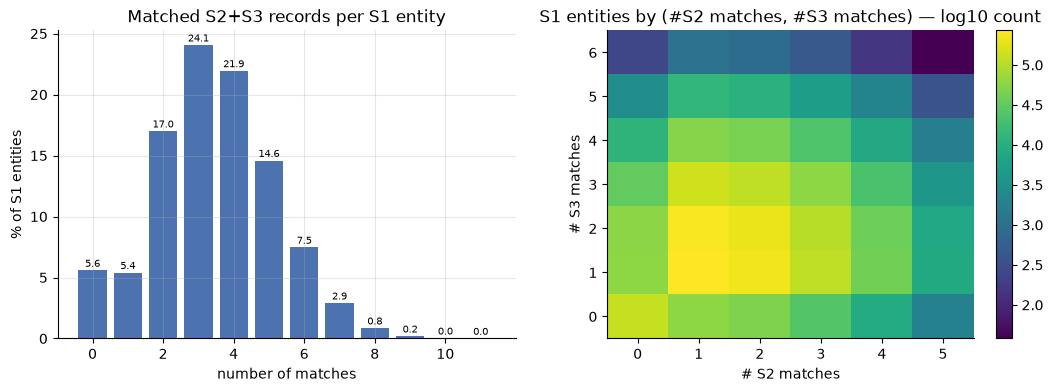

n_matches,s1_entities,pct
u32,u32,f64
0,123247,5.58
1,119157,5.4
2,375212,17.0
3,530841,24.05
4,484115,21.94
5,321957,14.59
6,164868,7.47
7,63968,2.9
8,18680,0.85


In [36]:
match_dist = gt.group_by("n_matches").len("s1_entities").sort("n_matches").with_columns(
    pct=(pl.col("s1_entities") / pl.col("s1_entities").sum() * 100).round(2))
save_table(match_dist, "06_gt_match_count_distribution")

s2s3 = gt.group_by("n_s2", "n_s3").len("s1_entities")
save_table(s2s3.sort("n_s2", "n_s3"), "06_gt_s2_vs_s3_counts")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(match_dist["n_matches"], match_dist["pct"], color="#4C72B0")
for x, y in zip(match_dist["n_matches"], match_dist["pct"]):
    axes[0].text(x, y + 0.3, f"{y:.1f}", ha="center", fontsize=7)
axes[0].set(title="Matched S2+S3 records per S1 entity", xlabel="number of matches", ylabel="% of S1 entities")
piv = s2s3.to_pandas().pivot(index="n_s3", columns="n_s2", values="s1_entities").fillna(0).sort_index(ascending=False)
im = axes[1].imshow(np.log10(piv.values + 1), cmap="viridis", aspect="auto")
axes[1].set_xticks(range(piv.shape[1]), piv.columns)
axes[1].set_yticks(range(piv.shape[0]), piv.index)
axes[1].set(title="S1 entities by (#S2 matches, #S3 matches) — log10 count", xlabel="# S2 matches", ylabel="# S3 matches")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1])
save_fig(fig, "06_gt_match_distribution")
match_dist

**Interpretation.** 7.64 M true links for 2.21 M S1 entities (mean 3.46, median 3, max 11). **5.6 % of entities are singletons**, 5.4 % have exactly one match, and 89 % have two or more. Links are split evenly between S2 (3.69 M) and S3 (3.94 M). An entity often has **several records in the same source**: the mode is 1–2 in S2 and 1–2 in S3, with up to 5–6 in one source. So S2 and S3 each contain within-source duplicates of the same business. No list contains a duplicate id.

### 6.2 Integrity and coverage checks (full data)

In [37]:
s1_ids = scan_source("train", "S1").select(s1_id="entity_id")
other_ids = scan_sources(["train"], ["S2", "S3"]).select(pl.col("entity_id").alias("m_id"), "source")

checks = {
    "GT S1 ids missing from train S1 file": collect(pairs.lazy().select("s1_id").unique().join(s1_ids, on="s1_id", how="anti").select(pl.len())).item(),
    "train S1 ids missing from GT": collect(s1_ids.join(gt.lazy().select("s1_id"), on="s1_id", how="anti").select(pl.len())).item(),
    "matched ids not found in train S2/S3": collect(pairs.lazy().join(other_ids, on="m_id", how="anti").select(pl.len())).item(),
    "matched ids assigned to >1 S1 entity": pairs.group_by("m_id").len().filter(pl.col("len") > 1).height,
}
coverage = collect(other_ids.join(pairs.lazy().select("m_id", matched=pl.lit(True)), on="m_id", how="left")
                   .group_by("source").agg(records=pl.len(), matched=pl.col("matched").is_not_null().sum()))
coverage = coverage.with_columns(pct_matched=(pl.col("matched") / pl.col("records") * 100).round(2)).sort("source")
for k, v in checks.items():
    print(f"{k:45s} {v:,}")
save_table(coverage, "06_gt_s2_s3_coverage")
coverage

GT S1 ids missing from train S1 file          0
train S1 ids missing from GT                  0
matched ids not found in train S2/S3          0
matched ids assigned to >1 S1 entity          0


source,records,matched,pct_matched
str,u32,u32,f64
"""S2""",5034616,3693619,73.36
"""S3""",5285603,3944746,74.63


In [38]:
# Country agreement between an S1 entity and its matched records, and singleton rate by country
s1_country = scan_source("train", "S1").select(s1_id="entity_id", s1_country="country")
m_country = scan_sources(["train"], ["S2", "S3"]).select(m_id="entity_id", m_country="country")
country_agree = collect(pairs.lazy().join(s1_country, on="s1_id").join(m_country, on="m_id")
                        .group_by("s1_country", "m_country").len("pairs")).sort("s1_country", "m_country")
singleton_by_country = collect(gt.lazy().join(s1_country, on="s1_id").group_by("s1_country").agg(
    s1_entities=pl.len(), pct_singleton=((pl.col("n_matches") == 0).mean() * 100).round(2),
    mean_matches=pl.col("n_matches").mean().round(2), mean_s2=pl.col("n_s2").mean().round(2),
    mean_s3=pl.col("n_s3").mean().round(2))).sort("s1_country")
save_table(singleton_by_country, "06_gt_by_country")
display(country_agree)
singleton_by_country

s1_country,m_country,pairs
str,str,u32
"""India""","""India""",3059843
"""US""","""US""",4578522


s1_country,s1_entities,pct_singleton,mean_matches,mean_s2,mean_s3
str,u32,f64,f64,f64,f64
"""India""",883188,5.59,3.46,1.68,1.79
"""US""",1323633,5.58,3.46,1.67,1.79


**Interpretation.** The ground truth is internally consistent:

* Every GT S1 id is in the S1 file and vice versa.
* Every matched id exists in train S2/S3.
* **No S2/S3 record is linked to more than one S1 entity**, so the target structure is a strict partition: each S2/S3 record belongs to at most one S1 cluster.
* 73.4 % of S2 and 74.6 % of S3 records are matched. The remaining **≈26 % are unmatched distractors** (≈2.7 M records).
* Matches **never cross countries**.
* The singleton rate (5.6 %) and matches per entity (3.46) are identical for the US and India.

### 6.3 Pair-level similarity of true matches (5 % hash sample of S1 entities, all their matches)

In [39]:
s1_text = scan_source("train", "S1").select(s1_id="entity_id", s1_name="business_name", s1_addr="business_address", country="country")
m_text = scan_sources(["train"], ["S2", "S3"]).select(m_id="entity_id", m_name="business_name", m_addr="business_address")

pair_sample = collect(
    hash_sample(pairs.lazy(), 5, col="s1_id")
    .join(s1_text, on="s1_id").join(m_text, on="m_id")
    .with_columns(s1_name_n=normalize_expr("s1_name"), m_name_n=normalize_expr("m_name"),
                  s1_addr_n=normalize_expr("s1_addr"), m_addr_n=normalize_expr("m_addr"))
    .with_columns(
        name_raw_equal=pl.col("s1_name") == pl.col("m_name"),
        name_norm_equal=pl.col("s1_name_n") == pl.col("m_name_n"),
        name_sorted_tokens_equal=pl.col("s1_name_n").str.split(" ").list.sort().list.join(" ")
                                 == pl.col("m_name_n").str.split(" ").list.sort().list.join(" "),
        addr_raw_equal=pl.col("s1_addr") == pl.col("m_addr"),
        addr_norm_equal=pl.col("s1_addr_n") == pl.col("m_addr_n"),
        name_jaccard=token_jaccard("s1_name_n", "m_name_n"),
        addr_jaccard=token_jaccard("s1_addr_n", "m_addr_n"),
        m_addr_missing=pl.col("m_addr").is_null(),
        m_name_non_latin=pl.col("m_name").str.contains(NON_LATIN_LETTER) & ~pl.col("s1_name").str.contains(NON_LATIN_LETTER),
    ))
print(f"sampled pairs: {pair_sample.height:,} from {pair_sample['s1_id'].n_unique():,} S1 entities")

pair_stats = pair_sample.group_by("country", "m_source").agg(
    pairs=pl.len(),
    *[(pl.col(c).mean() * 100).round(2).alias(f"pct_{c}") for c in
      ["name_raw_equal", "name_norm_equal", "name_sorted_tokens_equal", "addr_raw_equal", "addr_norm_equal",
       "m_addr_missing", "m_name_non_latin"]],
    name_jacc_median=pl.col("name_jaccard").median().round(3),
    addr_jacc_median=pl.col("addr_jaccard").median().round(3),
    pct_name_jacc_zero=((pl.col("name_jaccard") == 0).mean() * 100).round(2),
).sort("country", "m_source")
save_table(pair_stats, "06_true_pair_similarity")
pair_stats

sampled pairs: 380,805 from 104,064 S1 entities


country,m_source,pct_name_raw_equal,pct_name_norm_equal,pct_name_sorted_tokens_equal,pct_addr_raw_equal,pct_addr_norm_equal,pct_m_addr_missing,pct_m_name_non_latin,pairs,name_jacc_median,addr_jacc_median,pct_name_jacc_zero
str,str,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""India""","""S2""",2.78,14.82,19.39,0.0,11.89,3.85,23.62,73953,0.6,0.833,28.6
"""India""","""S3""",2.8,16.71,21.13,4.2,4.24,3.96,13.14,79049,0.6,0.692,19.77
"""US""","""S2""",6.02,25.5,31.08,0.0,13.97,4.9,0.0,110049,0.667,0.667,8.08
"""US""","""S3""",5.77,25.86,31.11,4.64,4.64,4.51,0.0,117754,0.667,0.455,7.9


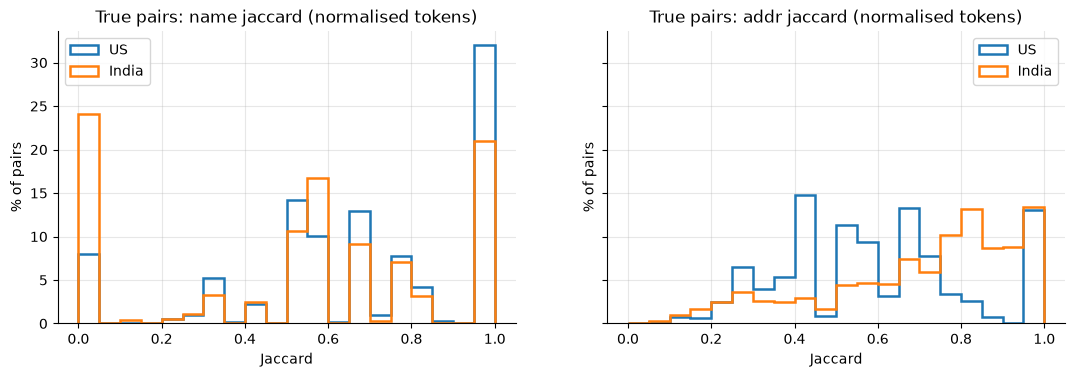

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
bins = np.linspace(0, 1, 21)
for ax, col in zip(axes, ["name_jaccard", "addr_jaccard"]):
    for (ctry,), d in pair_sample.group_by(["country"], maintain_order=True):
        vals = d[col].drop_nulls().to_numpy()
        ax.hist(vals, bins=bins, weights=np.ones_like(vals) * 100 / len(vals), histtype="step", lw=1.8, label=ctry)
    ax.set(title=f"True pairs: {col.replace('_', ' ')} (normalised tokens)", xlabel="Jaccard", ylabel="% of pairs")
    ax.legend()
save_fig(fig, "06_true_pair_jaccard")

**Interpretation.** Measured on 380,805 true pairs from a 5 % hash sample of S1 entities:

* **Only 3–6 % of true pairs have an identical raw name.** Conservative normalisation raises this to 15–17 % (India) and 25–26 % (US), and ignoring token order adds another ≈5 points.
* The median name-token Jaccard is only 0.60–0.67, and **8 % (US) to 29 % (India S2) of true pairs share no name token at all**. For India this is largely because of transliterated names.
* **S2 never reproduces the S1 address verbatim** (it is always reformatted and upper-cased). S3 copies it exactly in ≈4–5 % of pairs.
* The median address-token Jaccard is 0.46–0.83. It is highest for Indian S2, whose long addresses keep many tokens.

True matches are therefore **fuzzy**: no single exact key recovers most of them.

### 6.4 Representative true-match groups (real records)

In [41]:
def show_group(s1_id: str) -> pl.DataFrame:
    s1 = collect(scan_source("train", "S1").filter(pl.col("entity_id") == s1_id)
                 .select("entity_id", "business_name", "business_address", "country"))
    m = pair_sample.filter(pl.col("s1_id") == s1_id).select(
        entity_id="m_id", business_name="m_name", business_address="m_addr", country="country")
    return pl.concat([s1, m])


rep_ids = (pair_sample.join(gt.select("s1_id", "n_matches"), on="s1_id")
           .filter(pl.col("n_matches").is_between(3, 5)).group_by("country").agg(pl.col("s1_id").sort().first())
           .sort("country")["s1_id"].to_list())
for sid in rep_ids:
    display(show_group(sid))

entity_id,business_name,business_address,country
str,str,str,str
"""S1-100015511""","""Shashikant Welfare Private Limited""","""Vastushree, Office No.35, S.No. 587 Market Yard, Gultekadi, Pune, Maharashtra""","""India"""
"""S2-714243695""","""M/s SHASHIKANT WELFARE PRIVATE LTD""","""BLOCK G-858- VASTUSHREE, OFFICE NO.35, S.NO. 587 MARKET YARD, GULTEKADI, PUNE, महाराष्ट्र""","""India"""
"""S3-103915248""","""M/s Shashikant Welfare Private Limited""","""Vastushree, Office No.35, S.no. 587 Market Yard, Gultekadi, Pune, MH""","""India"""
"""S2-852783595""","""Shri Shashikant Welfare Privgaae Limited""","""BLOCK G-858- VASTUSHREE, OFFICE NO.35, S.NO. 587 MARKET YARD, GULTEKADI, PUNE, Maharashtra""","""India"""


entity_id,business_name,business_address,country
str,str,str,str
"""S1-10002925""","""Richardson Mexico, LLC""","""6515 W Fork Road, Cincinnati, OH""","""US"""
"""S3-22118984""","""Richardson México, LLC""",null,"""US"""
"""S3-380526896""","""Richardson LLC Mexico,""","""6515 1/2 West Fork Rd, Cincinnati, Ohio""","""US"""
"""S2-368118453""","""RICHARDSONMEXICO.COM""","""OH, WEST FORK ROAD, CINCINNATI""","""US"""
"""S3-592110166""","""Richardson Mexico,""",null,"""US"""


**Interpretation.** Typical clusters mix all noise types at once: `M/s` prefixes, `LTD` vs `Limited`, the typo `Privgaae`, upper-cased S2 addresses with extra `BLOCK G-858` components, and state codes vs state names. In the US example (*Richardson Mexico, LLC*) the same business appears with an accent (`México`), a reordered legal form, a domain name (`RICHARDSONMEXICO.COM`), a truncated name and missing addresses, in a single cluster.

### 6.5 Difficult / noisy true matches (real records)

In [42]:
HARD = {
    "no shared name token": pl.col("name_jaccard") == 0,
    "match name in non-Latin script": pl.col("m_name_non_latin"),
    "same tokens, different order": pl.col("name_sorted_tokens_equal") & ~pl.col("name_norm_equal"),
    "match address missing": pl.col("m_addr_missing"),
    "low address overlap (<0.2) despite equal name": pl.col("name_norm_equal") & (pl.col("addr_jaccard") < 0.2),
}
hard_counts = pl.DataFrame({"case": list(HARD), "pct_of_pairs": [round(pair_sample.select(e.mean()).item() * 100, 2) for e in HARD.values()]})
hard_examples = pl.concat([
    pair_sample.filter(e).sort("s1_id").group_by("country", maintain_order=True).head(2)
    .select(pl.lit(k).alias("case"), "country", "s1_name", "m_name", "s1_addr", "m_addr")
    for k, e in HARD.items()])
save_table(hard_counts, "06_hard_pair_rates")
save_table(hard_examples, "06_hard_pair_examples")
display(hard_counts)
hard_examples

case,pct_of_pairs
str,f64
"""no shared name token""",14.43
"""match name in non-Latin script""",7.32
"""same tokens, different order""",5.04
"""match address missing""",4.38
"""low address overlap (<0.2) despite equal name""",0.42


case,country,s1_name,m_name,s1_addr,m_addr
str,str,str,str,str,str
"""no shared name token""","""US""","""Richardson Mexico, LLC""","""RICHARDSONMEXICO.COM""","""6515 W Fork Road, Cincinnati, OH""","""OH, WEST FORK ROAD, CINCINNATI"""
"""no shared name token""","""US""","""Frontier Pyrophyte, Inc""","""Fpyrophyte.Com""","""60 Brookdale Road, Sudbury, MA""","""60 Brookdale Road, Sudbury, Massachusetts"""
"""no shared name token""","""India""","""Laxmi Universal Investment Private Limited""","""लक्ष्मी यूनिवर्सल इन्वेस्टमेंट प्राइवेट लिमिटेड""","""Shop No.1, Diamond Tower, Unitech Road, Virar West, Palghar, Thane, Maharashtra""","""SHOP NO.1, PALGHAR, THANE, Maharashtra"""
"""no shared name token""","""India""","""Dream Healthcare Pvt Ltd""","""డ్రీమ్ హెల్త్‌కేర్ ప్రైవేట్ లిమిటెడ్""","""Jubilee Hills, Telangana, Plot No.1112/A Road No.56, Hyderabad""","""Telangana, JUBILEE HILLS, PLOT NO.1112/A. ROAD NO.56, HYDERABAD"""
"""match name in non-Latin script""","""India""","""Laxmi Universal Investment Private Limited""","""लक्ष्मी यूनिवर्सल इन्वेस्टमेंट प्राइवेट लिमिटेड""","""Shop No.1, Diamond Tower, Unitech Road, Virar West, Palghar, Thane, Maharashtra""","""SHOP NO.1, PALGHAR, THANE, Maharashtra"""
"""match name in non-Latin script""","""India""","""Dream Healthcare Pvt Ltd""","""డ్రీమ్ హెల్త్‌కేర్ ప్రైవేట్ లిమిటెడ్""","""Jubilee Hills, Telangana, Plot No.1112/A Road No.56, Hyderabad""","""Telangana, JUBILEE HILLS, PLOT NO.1112/A. ROAD NO.56, HYDERABAD"""
"""same tokens, different order""","""US""","""Richardson Mexico, LLC""","""Richardson LLC Mexico,""","""6515 W Fork Road, Cincinnati, OH""","""6515 1/2 West Fork Rd, Cincinnati, Ohio"""
"""same tokens, different order""","""US""","""Beamon Midstream Inc.""","""INC. BEAMON MIDSTREAM""","""3424 Taylor Street, Fort Wayne, IN""","""Indiana, 3424 Tayolr St, Wayne"""
"""same tokens, different order""","""India""","""Laxmi Construction (India) Pvt Ltd""","""Laxmi Ltd (India) Pvt Construction""","""Haiwatmau Mawaiya Rbl Road, Lucknow, Uttar Pradesh""","""Haiwatmau Mawaiya Rbl Road, Lucknow, UP"""


**Interpretation.** Among sampled true pairs:

* 14.4 % share **no normalised name token**, mainly transliterations and domain-style names.
* 7.3 % have the match name in a **non-Latin script**.
* 5 % differ only in **token order**.
* 4.4 % have **no address** on the matched side.
* A small number (0.4 %) have an equal name but a clearly different address, e.g. a different city or a PO box added. These true matches look like false merges.

Each of these defeats a different simple heuristic.

## 7. Name vs address information

### 7.1 Within S1: how unique are name, address and name+address? (full data, normalised keys)

In [43]:
def ambiguity(split: str) -> pl.DataFrame:
    df = collect(scan_source(split, "S1").select(
        "country",
        name=normalize_expr("business_name"),
        addr=normalize_expr("business_address"),
        addr_digits=pl.col("business_address").str.extract_all(r"\d+").list.join(" "),
    ).with_columns(
        n_name=pl.len().over("name"), n_addr=pl.len().over("addr"),
        n_name_addr=pl.len().over("name", "addr"), n_name_digits=pl.len().over("name", "addr_digits"),
    ))
    agg = lambda: [
        pl.len().alias("rows"),
        ((pl.col("n_name") > 1).mean() * 100).round(2).alias("pct_name_shared"),
        ((pl.col("n_addr") > 1).mean() * 100).round(2).alias("pct_addr_shared"),
        ((pl.col("n_name_addr") > 1).mean() * 100).round(2).alias("pct_name+addr_shared"),
        ((pl.col("n_name_digits") > 1).mean() * 100).round(2).alias("pct_name+addr_digits_shared"),
        ((pl.col("n_name_addr") == 1).filter(pl.col("n_name") > 1).mean() * 100).round(2).alias("pct_repeated_names_resolved_by_addr"),
        ((pl.col("n_name_digits") == 1).filter(pl.col("n_name") > 1).mean() * 100).round(2).alias("pct_repeated_names_resolved_by_addr_digits"),
        pl.col("n_name").max().alias("max_name_group"),
    ]
    by_c = df.group_by("country").agg(*agg())
    total = df.select(pl.lit("ALL").alias("country"), *agg())
    return pl.concat([by_c.sort("country"), total]).with_columns(split=pl.lit(split))


amb = pl.concat([ambiguity(sp) for sp in SPLITS]).select("split", pl.all().exclude("split"))
save_table(amb, "07_s1_name_address_ambiguity")
amb

split,country,rows,pct_name_shared,pct_addr_shared,pct_name+addr_shared,pct_name+addr_digits_shared,pct_repeated_names_resolved_by_addr,pct_repeated_names_resolved_by_addr_digits,max_name_group
str,str,u32,f64,f64,f64,f64,f64,f64,u32
"""train""","""India""",883188,44.22,4.84,0.0,2.72,100.0,93.85,99
"""train""","""US""",1323633,35.84,5.62,0.0,0.22,100.0,99.39,253
"""train""","""ALL""",2206821,39.19,5.31,0.0,1.22,100.0,96.89,253
"""test""","""France""",259452,34.07,10.77,0.0,3.64,100.0,89.31,205
"""test""","""India""",809986,43.56,4.73,0.0,2.63,100.0,93.96,110
"""test""","""US""",663106,29.16,4.04,0.0,0.1,100.0,99.65,123
"""test""","""ALL""",1732544,36.63,5.37,0.0,1.81,100.0,95.05,205


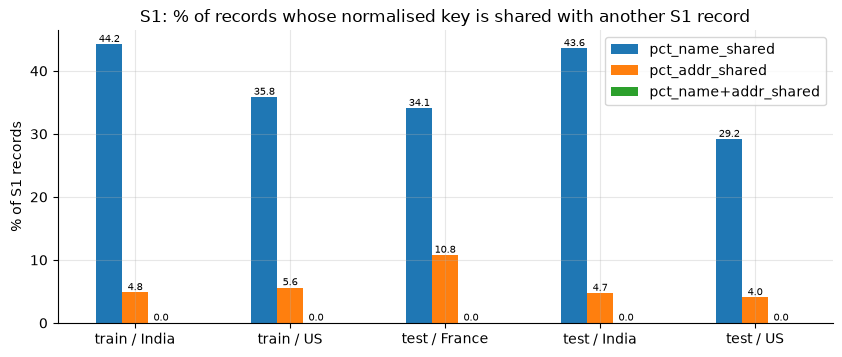

In [44]:
d = amb.filter(pl.col("country") != "ALL").to_pandas()
d["label"] = d["split"] + " / " + d["country"]
cols = ["pct_name_shared", "pct_addr_shared", "pct_name+addr_shared"]
fig, ax = plt.subplots(figsize=(10, 3.8))
d.set_index("label")[cols].plot.bar(ax=ax, rot=0)
ax.set(title="S1: % of records whose normalised key is shared with another S1 record", ylabel="% of S1 records", xlabel="")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f", fontsize=7)
save_fig(fig, "07_s1_key_ambiguity")

In [45]:
same_name_diff_addr = collect(scan_source("train", "S1").with_columns(k=normalize_expr("business_name"))
                              .filter(pl.len().over("k").is_between(2, 6)).sort("k", "entity_id")
                              .filter(pl.col("k").hash(SEED) % 500 == 0)
                              .select("k", "entity_id", "business_name", "business_address", "country").head(14))
same_name_diff_addr

k,entity_id,business_name,business_address,country
str,str,str,str,str
"""106 107 north owners corp""","""S1-254104863""","""106-107 North Owners Corp""","""57 Story Street, Boston, MA""","""US"""
"""106 107 north owners corp""","""S1-294019536""","""106-107 North Owners Corp""","""933 Varnum Avenue, Unit 1, Lowell, MA""","""US"""
"""157 seventh realty""","""S1-349625894""","""157 Seventh Realty""","""801 Holoway Drive, Midwest City, OK""","""US"""
"""157 seventh realty""","""S1-812967936""","""157 Seventh Realty""","""301 2nd Avenue, Belt, MT""","""US"""
"""4853 lake court apartments associates""","""S1-744508530""","""4853 Lake Court Apartments Associates""","""8068 Earl Avenue, Seattle, WA""","""US"""
"""4853 lake court apartments associates""","""S1-786556083""","""4853 Lake Court Apartments Associates""","""8755 Sieloff Drive, Unit UNIT D, Hazelwood, MO""","""US"""
"""aavas lifescience corporation""","""S1-18253261""","""Aavas Lifescience Corporation""","""C/O Harihar Sathua, Sarbodaya Nagar, Puri, Orissa, Puri, Orissa""","""India"""
"""aavas lifescience corporation""","""S1-205063078""","""Aavas Lifescience Corporation""","""1160, 11Th Floor, Near Ajnara Society Gaur Cascades, Rajnagar Extention, Ghaziabad, Uttar Pradesh""","""India"""
"""ace foundation llp""","""S1-14026990""","""Ace Foundation LLP""","""H. No. 417 P, R-3, Huda, Cheeka, Kaithal, Haryana""","""India"""


**Interpretation.** Within the reference source itself, **39 % of S1 records share their normalised name** with another S1 record (India 44 %, US 36 %, France 34 %). Only ≈5 % share their normalised address, and **none share name + address**, so address resolves 100 % of repeated S1 names by construction. A much coarser key, name + the digits in the address, still resolves ≈97 % of repeated names (≈89 % for France, where templated addresses repeat). The examples show that same-name S1 entities are different businesses in unrelated cities.

### 7.2 Exact-name decoys: do non-matching S2/S3 records share a true match's name? (5 % S1 sample)

In [46]:
s1_keys = collect(hash_sample(scan_source("train", "S1"), 5).select(s1_id="entity_id", country="country", k=normalize_expr("business_name")))
other_same_name = collect(scan_sources(["train"], ["S2", "S3"]).select(m_id="entity_id", k=normalize_expr("business_name"))
                          .join(s1_keys.lazy().select("k").unique(), on="k", how="semi"))
cand = s1_keys.join(other_same_name, on="k", how="inner").join(pairs.select("s1_id", "m_id", is_true=pl.lit(True)),
                                                                on=["s1_id", "m_id"], how="left")
per_s1 = cand.group_by("s1_id").agg(same_name_records=pl.len(), true_among_them=pl.col("is_true").is_not_null().sum())
decoy = (s1_keys.join(gt.select("s1_id", "n_matches"), on="s1_id").join(per_s1, on="s1_id", how="left").fill_null(0)
         .with_columns(decoys=pl.col("same_name_records") - pl.col("true_among_them"), singleton=pl.col("n_matches") == 0))
decoy_stats = decoy.group_by("country", "singleton").agg(
    s1_entities=pl.len(),
    pct_with_same_name_record=((pl.col("same_name_records") > 0).mean() * 100).round(2),
    pct_with_decoy=((pl.col("decoys") > 0).mean() * 100).round(2),
    median_decoys_when_any=pl.col("decoys").filter(pl.col("decoys") > 0).median(),
    exact_name_precision=(pl.col("true_among_them").sum() / pl.col("same_name_records").sum()).round(3),
    exact_name_recall=(pl.col("true_among_them").sum() / pl.col("n_matches").sum()).round(3),
).sort("country", "singleton")
save_table(decoy_stats, "07_exact_name_decoys")
decoy_stats

country,singleton,s1_entities,pct_with_same_name_record,pct_with_decoy,median_decoys_when_any,exact_name_precision,exact_name_recall
str,bool,u32,f64,f64,f64,f64,f64
"""India""",false,41777,70.24,41.25,7.0,0.153,0.158
"""India""",true,2484,40.86,40.86,7.0,0.0,NaN
"""US""",false,62287,74.14,35.53,6.0,0.067,0.257
"""US""",true,3772,35.23,35.23,6.0,0.0,NaN


In [47]:
decoy_examples = (cand.filter(pl.col("is_true").is_null()).join(s1_keys.select("s1_id"), on="s1_id")
                  .sort("s1_id").unique("s1_id", keep="first", maintain_order=True).head(6)
                  .join(s1_text.select("s1_id", "s1_name", "s1_addr").collect(), on="s1_id")
                  .join(collect(m_text.join(pl.LazyFrame({"m_id": cand.filter(pl.col("is_true").is_null())["m_id"].unique()}), on="m_id", how="semi")),
                        on="m_id")
                  .select("s1_id", "s1_name", "s1_addr", "m_id", "m_name", "m_addr"))
decoy_examples

s1_id,s1_name,s1_addr,m_id,m_name,m_addr
str,str,str,str,str,str
"""S1-100115868""","""Ear Nose & Throat Specialists Corp""","""1553 Lady Brunetta Road, Bradley, IL""","""S3-252629392""","""Ear Nose & Throat Specialists Corp""","""Montana, Billigs, 805 Westgate Dr"""
"""S1-100085891""","""Dream Healthcare Pvt Ltd""","""Jubilee Hills, Telangana, Plot No.1112/A Road No.56, Hyderabad""","""S2-371539194""","""Dream Healthcare Pvt Ltd.""","""BLOCK G-571 E-52/137, ARADHAK NAGAR, SHAHDRA, DELHI, Delhi"""
"""S1-10002925""","""Richardson Mexico, LLC""","""6515 W Fork Road, Cincinnati, OH""","""S3-729831870""",""">> Richardson Mexico, LLC""","""4728-B Ocean Beach Hwy, # 3, Longview, Washington"""
"""S1-100060833""","""Frontier Pyrophyte, Inc""","""60 Brookdale Road, Sudbury, MA""","""S3-300935785""","""Frontier Pyrophyte, (Inc)""",null
"""S1-100142593""","""Pediatric Dental Grand Group""","""2812 149th Street, Urbandale, IA""","""S3-564077581""","""Pediatric Dental Grand-(Group)""","""4067-C Aster Drive, Phooenix, Arizona"""
"""S1-100142077""","""Integrated Generation LLC""","""1931 Gallagher Street, Dallas, TX""","""S2-519746035""","""Integrated Generation [LLC]""","""587 POLK ST, MARINO, OH"""


**Interpretation.** This is the key precision risk. For a 5 % sample of S1 entities, all S2/S3 records whose normalised name **exactly equals** the S1 name were counted:

* **35–41 % of matched S1 entities have at least one same-name S2/S3 record that is not their match.** These decoys typically belong to another S1 entity with the same name.
* The same holds for **35–41 % of singletons**. A name-only rule would give them a false match and a score of 0.
* Across all such same-name records, only 7 % (US) to 15 % (India) are true matches, because generic names contribute many decoys.
* Exact names also recover only 16–26 % of true links.

The decoy examples show identical names at completely different addresses (`Ear Nose & Throat Specialists Corp`: IL vs MT). **Name similarity alone is neither precise nor sufficient; address evidence is essential for precision.**

## 8. Train vs test

### 8.1 Country mix and size (full data)

In [48]:
split_country = order(collect(scan_sources().group_by("split", "country").len("rows"))
                      .with_columns(pct=(pl.col("rows") / pl.col("rows").sum().over("split") * 100).round(2)))
sizes = order(collect(scan_sources().group_by("split", "source").len("rows")))
ratio = sizes.pivot(on="source", index="split", values="rows").with_columns(
    S2_per_S1=(pl.col("S2") / pl.col("S1")).round(2), S3_per_S1=(pl.col("S3") / pl.col("S1")).round(2))
save_table(split_country, "08_train_test_country")
save_table(ratio, "08_train_test_source_ratios")
display(split_country)
ratio

split,country,rows,pct
str,str,u32,f64
"""train""","""India""",5016534,40.05
"""train""","""US""",7510506,59.95
"""test""","""France""",1694445,14.48
"""test""","""India""",5527551,47.24
"""test""","""US""",4480137,38.28


split,S1,S2,S3,S2_per_S1,S3_per_S1
str,u32,u32,u32,f64,f64
"""train""",2206821,5034616,5285603,2.28,2.4
"""test""",1732544,4887273,5082316,2.82,2.93


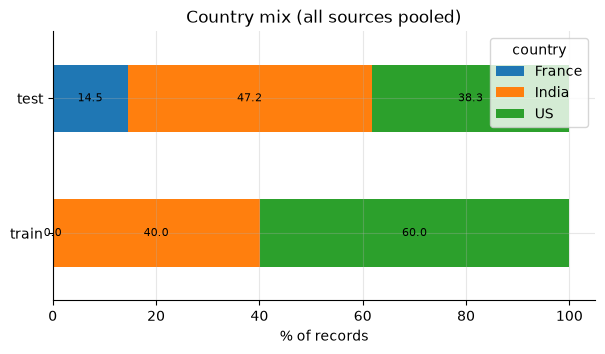

In [49]:
fig, ax = plt.subplots(figsize=(7, 3.5))
p = split_country.to_pandas().pivot(index="split", columns="country", values="pct").fillna(0).loc[SPLITS]
p.plot.barh(stacked=True, ax=ax)
ax.set(title="Country mix (all sources pooled)", xlabel="% of records", ylabel="")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f", label_type="center", fontsize=8)
save_fig(fig, "08_train_test_country_mix")

**Interpretation.** The test country mix differs from train: **France 14.5 % (new)**, India up from 40 % to 47 %, and US down from 60 % to 38 %. Test also has **more S2/S3 records per S1** (2.8–2.9 vs 2.3–2.4), so each test S1 entity faces more candidate records. That could mean more matches per entity and/or more distractors.

### 8.2 Length and missingness by split × country (full data)

In [50]:
tt_profile = order(collect(scan_sources().group_by("split", "country", "source").agg(
    pl.len().alias("rows"), *text_profile("business_name", "name"), *text_profile("business_address", "addr"))))
save_table(tt_profile, "08_train_test_profile")
tt_profile.select("split", "country", "source", "rows", "name_len_median", "name_words_mean", "addr_pct_null",
                  "addr_len_median", "addr_words_mean")

split,country,source,rows,name_len_median,name_words_mean,addr_pct_null,addr_len_median,addr_words_mean
str,str,str,u32,f64,f64,f64,f64,f64
"""train""","""India""","""S1""",883188,27.0,3.74,0.0,76.0,11.23
"""train""","""US""","""S1""",1323633,22.0,3.42,0.0,34.0,5.9
"""train""","""India""","""S2""",2017799,27.0,3.71,2.87,69.0,10.37
"""train""","""US""","""S2""",3016817,23.0,3.35,3.68,32.0,5.63
"""train""","""India""","""S3""",2115547,27.0,3.69,3.07,60.0,9.4
"""train""","""US""","""S3""",3170056,23.0,3.42,3.5,39.0,6.09
"""test""","""France""","""S1""",259452,19.0,3.11,0.0,48.0,7.22
"""test""","""India""","""S1""",809986,27.0,3.74,0.0,76.0,11.23
"""test""","""US""","""S1""",663106,22.0,3.42,0.0,34.0,5.9


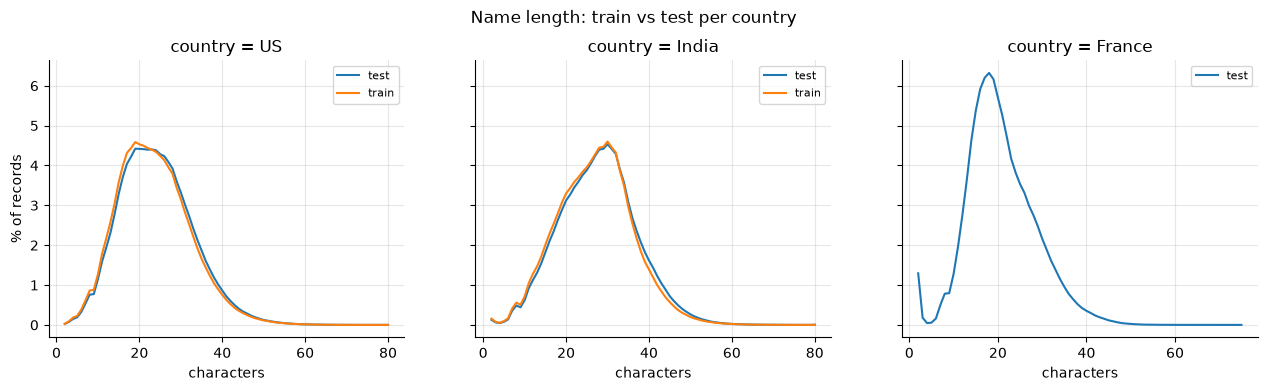

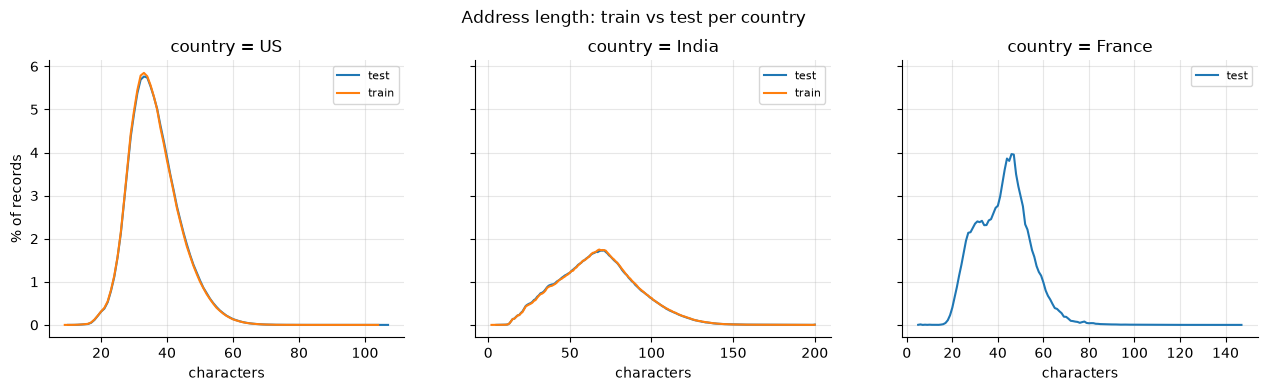

In [51]:
lf_sc = scan_sources().with_columns(sc=pl.col("split") + "-" + pl.col("source"))
h_n = value_hist(lf_sc, n_chars("business_name"), by=("country", "split"), clip=80)
h_a = value_hist(lf_sc.filter(pl.col("business_address").is_not_null()), n_chars("business_address"), by=("country", "split"), clip=200)
plot_hist_panels(h_n, "country", "split", "Name length: train vs test per country", "characters", "08_train_test_name_length")
plot_hist_panels(h_a, "country", "split", "Address length: train vs test per country", "characters", "08_train_test_address_length")

**Interpretation.** For the **US and India, train and test are statistically indistinguishable**: the same medians, word counts and length curves, and a slightly lower missing-address rate in test. The shift is almost entirely **the arrival of France**, which has shorter names (median 19–20 characters, 3.1 words) and mid-length addresses (median 41–48 characters, a bimodal curve).

### 8.3 Noise-pattern shift by country (full data)

In [52]:
tt_flags = flag_rates(scan_sources(), "business_name", {k: name_flags[k] for k in
                      ["non_ascii", "latin_diacritics", "non_latin_script", "url_or_domain", "all_upper", "repeated_space"]},
                      by=("split", "country"))
tt_aflags = flag_rates(scan_sources(), "business_address", {k: addr_flags[k] for k in
                       ["non_ascii", "latin_diacritics", "non_latin_script", "all_upper", "odd_symbols"]},
                       by=("split", "country"))
save_table(tt_flags, "08_train_test_name_flags")
save_table(tt_aflags, "08_train_test_address_flags")
display(tt_flags)
tt_aflags

split,country,rows,non_ascii,latin_diacritics,non_latin_script,url_or_domain,all_upper,repeated_space
str,str,u32,f64,f64,f64,f64,f64,f64
"""train""","""India""",5016534,19.01,4.0,15.01,2.9,7.1,8.48
"""train""","""US""",7510506,5.56,5.56,0.0,3.55,10.01,9.38
"""test""","""France""",1694445,22.93,22.93,0.0,2.93,11.06,7.21
"""test""","""India""",5527551,19.48,3.79,15.69,2.44,6.98,8.56
"""test""","""US""",4480137,5.39,5.39,0.0,3.03,9.92,9.47


split,country,rows,non_ascii,latin_diacritics,non_latin_script,all_upper,odd_symbols
str,str,u32,f64,f64,f64,f64,f64
"""train""","""India""",4893740,19.52,0.05,19.48,9.86,9.93
"""train""","""US""",7288417,0.0,0.0,0.0,37.18,7.4
"""test""","""France""",1651367,25.46,21.52,0.0,12.34,2.83
"""test""","""India""",5415547,20.37,0.05,20.33,10.27,10.68
"""test""","""US""",4369713,0.0,0.0,0.0,38.75,7.74


**Interpretation.** Per-country noise rates are stable between train and test for the US and India, e.g. Indian non-Latin names 15.0 % → 15.7 % and US all-caps addresses 37 % → 39 %. France has a new profile: **≈23 % of names and ≈21 % of addresses contain genuine French diacritics** (é, è, ç), but no non-Latin script. For France, accents are legitimate spelling that the noise sometimes drops or alters (`ECOLE` vs `École`, `Sàrl`), so accent folding matters there in a way it does not for the US and India.

### 8.4 France (test only) — what does it look like?

In [53]:
france_examples = pl.concat([collect(hash_sample(scan_source("test", s), 1).filter(pl.col("country") == "France").head(4)
                                     .select("entity_id", "business_name", "business_address")) for s in SOURCES])
france_examples

entity_id,business_name,business_address
str,str,str
"""S1-889012090""","""Deuxieme Groupe""","""36 Rue Armand Gayral, Mérignac, Nouvelle-Aquitaine"""
"""S1-438186667""","""Team Agricole""","""1 Rue Marie Tudor, Calais, Hauts-de-France"""
"""S1-429851261""","""Commission Amicale""","""37 RUE Frere, Bordeaux, Nouvelle-Aquitaine"""
"""S1-731314679""","""Ets Art SARL""","""123 Rue Decrême, Roubaix, Hauts-de-France"""
"""S2-823495263""","""Lycée Dame Cie""","""19 AVENUE RENE DE MOULINS DE ROCHEOFRT, LA BAULE-ESCOUBLAC, Loire-Atlantique"""
"""S2-956952534""","""PATRICIA SPORTIVE SARL""","""8 RUE DE GIEANT, ETAGE 3 - APPARTEMENT 13, NANTES, Pays de la Loire"""
"""S2-169037041""","""Ets Rivage SARL Et Fils""","""6 R JEAN JACQUES ROUSSEAU, NANTES, Pays de la Loire"""
"""S2-375101252""","""Sechoir Soins""","""15 RUE DU GABD, LILLE, Hauts-de-France"""
"""S3-137807983""","""Madeleines (France) Culturel Sàrl""","""No 31 Imp Raphael, Nantes"""


In [54]:
def top_tokens(split: str, country: str, col: str, k: int = 25, pct: float = 5) -> pl.DataFrame:
    return collect(hash_sample(scan_sources([split]), pct).filter(pl.col("country") == country)
                   .select(t=normalize_expr(col).str.split(" ")).explode("t")
                   .filter(pl.col("t").str.len_chars() > 0).group_by("t").len("n").sort("n", descending=True).head(k))


tok = pl.concat([top_tokens(sp, c, col).select(pl.lit(f"{sp}/{c}/{col.split('_')[1]}").alias("slice"),
                                                pl.concat_str("t", pl.lit(" ("), "n", pl.lit(")")).alias("token"),
                                                pl.int_range(pl.len()).alias("rank"))
                 for sp, c in [("train", "US"), ("train", "India"), ("test", "France")] for col in TEXT_COLS])
top_tok = tok.pivot(on="slice", index="rank", values="token")
save_table(top_tok, "08_top_tokens_by_country")
top_tok

rank,train/US/name,train/US/address,train/India/name,train/India/address,test/France/name,test/France/address
i64,str,str,str,str,str,str
0,"""llc (73430)""","""street (41910)""","""limited (86380)""","""no (132424)""","""sarl (17900)""","""de (51931)"""
1,"""inc (53135)""","""road (38326)""","""private (80167)""","""delhi (63651)""","""sas (12718)""","""rue (36245)"""
2,"""& (18438)""","""drive (33790)""","""ltd (39957)""","""road (50452)""","""france (7817)""","""la (23731)"""
3,"""l (17153)""","""st (33011)""","""pvt (26723)""","""nagar (38197)""","""club (5941)""","""r (17881)"""
4,"""center (16174)""","""rd (30243)""","""लिमिटेड (14950)""","""floor (37567)""","""de (5061)""","""loire (16463)"""
5,"""partners (14760)""","""avenue (28004)""","""india (14598)""","""c (29518)""","""eurl (4933)""","""france (14604)"""
6,"""and (14716)""","""dr (27242)""","""प्राइवेट (12416)""","""mumbai (28865)""","""& (4922)""","""hauts (14435)"""
7,"""c (14089)""","""city (24872)""","""services (9360)""","""1 (28059)""","""s (4913)""","""bordeaux (13819)"""
8,"""corp (13389)""","""ave (22859)""","""llp (9128)""","""a (26729)""","""sa (4079)""","""nouvelle (12030)"""


In [55]:
# Overlap between splits: shared ids / shared normalised S1 names
ids_overlap = collect(scan_sources(["train"]).select("entity_id").join(scan_sources(["test"]).select("entity_id"), on="entity_id", how="semi").select(pl.len())).item()
name_overlap = collect(scan_source("test", "S1").select("country", k=normalize_expr("business_name"))
                       .join(scan_source("train", "S1").select(k=normalize_expr("business_name")).unique(), on="k", how="left", coalesce=False)
                       .group_by("country").agg(test_s1=pl.len(), pct_name_seen_in_train_s1=(pl.col("k_right").is_not_null().mean() * 100).round(2)))
print(f"entity_ids appearing in both train and test: {ids_overlap:,}")
name_overlap.sort("country")

entity_ids appearing in both train and test: 0


country,test_s1,pct_name_seen_in_train_s1
str,u32,f64
"""France""",259452,0.01
"""India""",809986,44.22
"""US""",663106,35.87


**Interpretation.** French records look like `36 Rue Armand Gayral, Mérignac, Nouvelle-Aquitaine`: house number + `rue/avenue/boulevard` + city + region, abbreviated in S2/S3 (`R`, `R.`, `Imp`, `N°`), plus French legal forms (SARL, SAS, SASU, EURL, SCI, SNC) and generic association words (*club, amicale, comité, maison, école*). The vocabulary barely overlaps with train: **only 0.01 % of test French S1 names occur in train S1**, whereas ≈36–44 % of test US/India names do (common generic names). No `entity_id` is shared between train and test. **Nothing France-specific can be learned from labels; it must come from language-agnostic features.**

## 9. Key Findings

### Major data-quality and noise patterns
* **S1 is clean and the noise lives in S2/S3.** S1 has no missing values, no non-ASCII text outside France, no casing anomalies, and every address present. S2/S3 contain every kind of injected noise: punctuation (≈⅓), repeated spaces (≈11 %), domain names (≈4 %), bracket or star symbols (≈5 %), digit-for-letter typos (`Hea1th`), fake accents, legal forms moved to the front (3–5 %), missing addresses (≈3 %), and non-Latin scripts (≈15 % of Indian names, ≈20 % of Indian addresses).
* **Each source has its own formatting.** S2 upper-cases ≈18 % of names and 52–66 % of addresses. S3 writes US states in full but abbreviates Indian states. S2/S3 abbreviate street types about half the time, whereas S1 writes them in full.
* **Countries have very different address shapes.** US addresses are short and number-first. Indian addresses are long and landmark/C-o heavy (≈5.7 segments) and rarely number-first. French addresses are rue-based, and many are templated. Postcodes are rare, so they cannot be a key.
* **The files are well-formed.** All files parse cleanly, ids are unique, there is no train/test id overlap, and the ground truth is fully consistent.

### Name vs address importance
* **Names alone are ambiguous.** 39 % of S1 records share their normalised name with another S1 record. 35–41 % of S1 entities (including singletons) have an exact same-name S2/S3 record that is *not* their match, and exact-name agreement is right only 7–15 % of the time.
* **Address is what separates same-named businesses.** S1 is de-duplicated on (name, address), and even name + address digits separates ≈97 % of repeated names.
* **Neither field is reliable on its own for true matches.** Only 15–26 % of true pairs have equal normalised names, 8–29 % share no name token (transliteration, domain names), and S2 never copies the S1 address verbatim. Matching evidence therefore has to combine fuzzy name *and* fuzzy address similarity, with the country as a hard partition.

### Ground-truth structure
* 2.21 M S1 entities → 7.64 M links (mean 3.46, median 3, max 11). **5.6 % are singletons**, 5.4 % have one match, and 89 % have two or more. Links split evenly between S2 and S3, and several records of the same source often belong to one entity.
* **Each S2/S3 record belongs to at most one S1 entity**, and links **never cross countries**.
* **≈26 % of S2/S3 records match nothing** (≈2.7 M distractors).

### Train vs test differences
* **France is test-only** (≈14.5 % of test records, 259 k S1 entities). It has its own legal forms, vocabulary, genuine diacritics (≈23 % of names) and templated names/addresses. 0.01 % of its names appear in train.
* The country mix shifts from US 60 / India 40 in train to India 47 / US 38 / France 14.5 in test.
* Test has more S2/S3 records per S1 (2.8–2.9 vs 2.3–2.4).
* For the US and India, train and test distributions (lengths, missingness, noise rates) are practically identical.

### Implications for the next modelling phase (not a model design)
1. **Use `country` as a hard block.** Matches never cross countries, and every country (including France) must be handled without special-casing.
2. **Candidate generation must tolerate** token reordering, abbreviations, digit/letter typos, domain-style concatenations (`RICHARDSONMEXICO.COM`), missing addresses, and **non-Latin transliterations**. An exact-name key would miss 74–85 % of true links, so use character-level and/or multilingual representations rather than exact tokens.
3. **For precision (F0.5), address evidence is essential.** Same-name decoys are pervasive, and generic or templated names (medical groups, French clubs) are the riskiest. Features should capture house-number and address-digit agreement, city and state agreement, and missing-address status.
4. **Handle singletons explicitly** (5.6 %). About 38 % of them have a same-name decoy, so the matcher needs a calibrated "no match" decision, not just top-k retrieval.
5. **Use the one-cluster-per-record constraint.** Each S2/S3 record belongs to at most one S1 entity, which allows conflict resolution across S1 entities during post-processing.
6. **Keep normalisation conservative and reversible.** Lower-case, NFKC, punctuation and whitespace fixes are safe and useful (they collapse 7–8 % of S2/S3 name variants). Abbreviation expansion, legal-form stripping and accent folding should be *features or options*, not destructive preprocessing. Accents are real in French.
7. **Validate on a country-stratified split and plan for the France shift.** No French labels exist, so features must be language-agnostic. Train-only statistics (e.g. token frequencies) must be recomputed on test data to cover French vocabulary.

In [56]:
print(f"Notebook runtime: {(time.time() - T0) / 60:.1f} min")
print("Saved results:")
for p in sorted(OUT.iterdir()):
    print(f"  {p.name:55s} {p.stat().st_size / 1024:8.1f} KB")

Notebook runtime: 9.1 min
Saved results:
  01_country_distribution.csv                                  0.4 KB
  01_country_distribution.png                                 41.2 KB
  01_file_overview.csv                                         0.6 KB
  02_address_length_by_source.png                             65.0 KB
  02_address_words_by_source.png                              58.5 KB
  02_duplicate_group_sizes.png                                71.9 KB
  02_duplicate_group_sizes_train.csv                          14.4 KB
  02_duplicates_raw.csv                                        1.1 KB
  02_name_length_by_source.png                                64.6 KB
  02_name_words_by_source.png                                 65.4 KB
  02_source_profile.csv                                        0.7 KB
  03_legal_forms.csv                                           2.3 KB
  03_name_flags_by_country.csv                                 0.6 KB
  03_name_flags_by_source.csv                    